# TFM — Modelos predictivos para la optimización del consumo energético en la climatización de edificios
## Bloque 1: Carga, unión y limpieza de datos (E3Lab Grafana)

**Edificio:** ETSA — Universidad de Navarra, campus de Pamplona  
**Resolución temporal:** 15 minutos  
**Periodo cubierto:** Mayo 2023 – Diciembre 2025

---

### Estructura del notebook
1. Importación de librerías
2. Carga y unión de los CSVs
3. Limpieza y normalización de nombres de columnas
4. Análisis de nulos y cobertura temporal
5. Estrategia de imputación / eliminación de columnas
6. Exportación del dataset limpio
7. Visualización exploratoria rápida

## 1. Importación de librerías

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import re
import os
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


os.makedirs('Graficos', exist_ok=True)
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga y unión de los CSVs

Los archivos Grafana tienen columnas con metadatos embebidos en el nombre, del tipo:  
`CO2 {dir="dir_02", name="co2", planta="P1", uso="Aulas", zona="B"}`

El primer CSV (mayo–sept 2023) tiene **92 columnas** (sin variables energéticas).  
Los siguientes tienen **113 columnas** (con Caudal, Potencia, Energía, Volumen, Diferencia Temperatura).  
Al hacer `pd.concat` con `axis=0`, las columnas ausentes en el primer archivo quedarán como `NaN` para ese periodo, lo cual es correcto.

In [49]:
DATA_DIR = Path("E3Lab Grafana Datos")

CSV_FILES = [
    # ── 2023 ───────────────────────────────────────────
    DATA_DIR / "E3Lab Grafana 2023-05-12-2023-09-30.csv",
    DATA_DIR / "E3Lab Grafana 2023-09-30-2023-12-31.csv",
    # ── 2024 ───────────────────────────────────────────
    DATA_DIR / "E3Lab Grafana 2024-01-01-2024-05-31.csv",
    DATA_DIR / "E3Lab Grafana 2024-05-31-2024-09-30.csv",
    DATA_DIR / "E3Lab Grafana 2024-09-30-2024-12-31.csv",
    # ── 2025 ───────────────────────────────────────────
    DATA_DIR / "E3Lab Grafana 2025-01-01-2025-05-31.csv",
    DATA_DIR / "E3Lab Grafana 2025-05-31-2025-10-07.csv",
    DATA_DIR / "E3Lab Grafana 2025-10-07-2025-12-08.csv",
]

for f in CSV_FILES:
    status = "ENCONTRADO -" if f.exists() else "NO ENCONTRADO"
    print(f"{status} {f.name}")

ENCONTRADO - E3Lab Grafana 2023-05-12-2023-09-30.csv
ENCONTRADO - E3Lab Grafana 2023-09-30-2023-12-31.csv
ENCONTRADO - E3Lab Grafana 2024-01-01-2024-05-31.csv
ENCONTRADO - E3Lab Grafana 2024-05-31-2024-09-30.csv
ENCONTRADO - E3Lab Grafana 2024-09-30-2024-12-31.csv
ENCONTRADO - E3Lab Grafana 2025-01-01-2025-05-31.csv
ENCONTRADO - E3Lab Grafana 2025-05-31-2025-10-07.csv
ENCONTRADO - E3Lab Grafana 2025-10-07-2025-12-08.csv


In [50]:
dfs = []
for path in CSV_FILES:
    if not path.exists():
        print(f'Saltando archivo no encontrado: {path}')
        continue
    df_tmp = pd.read_csv(path, parse_dates=['Time'])
    print(f'{path.name}: {df_tmp.shape[0]:,} filas y {df_tmp.shape[1]} columnas  '
          f'| {df_tmp["Time"].min().date()} hasta {df_tmp["Time"].max().date()}')
    dfs.append(df_tmp)

df_raw = pd.concat(dfs, axis=0, ignore_index=True)
df_raw = df_raw.sort_values('Time').reset_index(drop=True)

print(f'\nDataset unificado: {df_raw.shape[0]:,} filas y {df_raw.shape[1]} columnas')
print(f'   Periodo: {df_raw["Time"].min()} hasta {df_raw["Time"].max()}')

E3Lab Grafana 2023-05-12-2023-09-30.csv: 13,564 filas y 92 columnas  | 2023-05-12 hasta 2023-09-30
E3Lab Grafana 2023-09-30-2023-12-31.csv: 8,932 filas y 113 columnas  | 2023-09-30 hasta 2023-12-31
E3Lab Grafana 2024-01-01-2024-05-31.csv: 14,672 filas y 113 columnas  | 2023-12-31 hasta 2024-05-31
E3Lab Grafana 2024-05-31-2024-09-30.csv: 11,807 filas y 113 columnas  | 2024-05-31 hasta 2024-09-30
E3Lab Grafana 2024-09-30-2024-12-31.csv: 8,932 filas y 113 columnas  | 2024-09-30 hasta 2024-12-31
E3Lab Grafana 2025-01-01-2025-05-31.csv: 14,537 filas y 113 columnas  | 2024-12-31 hasta 2025-05-31
E3Lab Grafana 2025-05-31-2025-10-07.csv: 12,052 filas y 113 columnas  | 2025-05-31 hasta 2025-10-07
E3Lab Grafana 2025-10-07-2025-12-08.csv: 6,052 filas y 113 columnas  | 2025-10-07 hasta 2025-12-08

Dataset unificado: 90,548 filas y 113 columnas
   Periodo: 2023-05-12 12:15:00 hasta 2025-12-08 23:59:59


## 3. Limpieza y normalización de nombres de columnas

Extraemos los metadatos del nombre original y creamos nombres cortos y legibles

In [51]:
TIPO_CORTO = {
    'CO2':                     'CO2',
    'Humedad Relativa':        'HUM',
    'Temperatura':             'TEMP',
    'Temperatura Impulsion':   'TIMP',
    'Temperatura Retorno':     'TRET',
    'Temperatura Radiante':    'TRAD',
    'Temperatura Terreno':     'TTER',
    'Diferencia Temperatura':  'TDIF',
    'Caudal':                  'CAUD',
    'Potencia':                'POT',
    'Energia':                 'ENER',
    'Volumen':                 'VOL',
}

def parse_grafana_col(col):
    """Devuelve (nombre_corto, dict_metadatos) para una columna Grafana."""
    m = re.match(r'^(.+?)\s*\{(.+)\}$', col)
    if not m:
        return col, {} 
    tipo_raw = m.group(1).strip()
    meta_str = m.group(2)
    meta = {}
    for part in re.split(r',\s*(?=[a-z_]+=)', meta_str):
        kv = part.split('=')
        if len(kv) >= 2:
            meta[kv[0].strip()] = kv[1].strip().strip('"')
    
    tipo_corto = TIPO_CORTO.get(tipo_raw, tipo_raw.replace(' ', '_'))
    dir_num    = meta.get('dir', '').replace('dir_', '')
    planta     = meta.get('planta', '')
    uso        = meta.get('uso', '').replace(' ', '_')[:8]  
    zona       = meta.get('zona', '')
    
    nombre_corto = f'{tipo_corto}_d{dir_num.zfill(2)}_{planta}_{uso}_{zona}'
    return nombre_corto, meta

col_map   = {}   
meta_rows = []   

for col in df_raw.columns:
    if col == 'Time':
        col_map[col] = 'timestamp'
        continue
    nombre_corto, meta = parse_grafana_col(col)
    base = nombre_corto
    n = 1
    while nombre_corto in col_map.values():
        nombre_corto = f'{base}_v{n}'
        n += 1
    col_map[col] = nombre_corto
    meta_rows.append({'col_original': col, 'col_corta': nombre_corto, **meta})

df_meta = pd.DataFrame(meta_rows)
df_raw  = df_raw.rename(columns=col_map)

print(f'Columnas renombradas. Ejemplo de mapeo:')
for orig, corto in list(col_map.items())[1:6]:
    print(f'  {orig[:60]:<60} → {corto}')

Columnas renombradas. Ejemplo de mapeo:
  CO2 {dir="dir_02", name="co2", planta="P1", uso="Aulas", zon → CO2_d02_P1_Aulas_B
  CO2 {dir="dir_03", name="co2", planta="P1", uso="Comun", zon → CO2_d03_P1_Comun_B
  CO2 {dir="dir_05", name="co2", planta="P1", uso="Aulas", zon → CO2_d05_P1_Aulas_C
  CO2 {dir="dir_07", name="co2", planta="P1", uso="Capilla", z → CO2_d07_P1_Capilla_A
  CO2 {dir="dir_09", name="co2", planta="P0", uso="Laboratorio → CO2_d09_P0_Laborato_C


In [52]:
df_meta[['col_corta', 'dir', 'name', 'planta', 'uso', 'zona']].head(20)

,col_corta,dir,name,planta,uso,zona
0,CO2_d02_P1_Aulas_B,dir_02,co2,P1,Aulas,B
1,CO2_d03_P1_Comun_B,dir_03,co2,P1,Comun,B
2,CO2_d05_P1_Aulas_C,dir_05,co2,P1,Aulas,C
3,CO2_d07_P1_Capilla_A,dir_07,co2,P1,Capilla,A
4,CO2_d09_P0_Laborato_C,dir_09,co2,P0,Laboratorio,C
5,CO2_d12_P0_Aulas_B,dir_12,co2,P0,Aulas,B
6,CO2_d13_P0_Comun_A,dir_13,co2,P0,Comun,A
7,CO2_d14_P0_Aula_Mag_A,dir_14,co2,P0,Aula Magna,A
8,CO2_d19_P3_Despacho_B,dir_19,co2,P3,Despachos,B
9,CO2_d20_P3_Despacho_B,dir_20,co2,P3,Despachos,B


## 4. Análisis de nulos y cobertura temporal

In [53]:
df_raw = df_raw.set_index("timestamp")

n_dupl = df_raw.index.duplicated().sum()
if n_dupl > 0:
    print(f"Timestamps duplicados detectados: {n_dupl} - se conserva el primero")
    df_raw = df_raw[~df_raw.index.duplicated(keep="first")]
else:
    print("Sin duplicados temporales")

idx_completo = pd.date_range(
    start=df_raw.index.min(),
    end=df_raw.index.max(),
    freq="15min"
)
registros_esperados = len(idx_completo)
registros_reales    = len(df_raw)
huecos              = registros_esperados - registros_reales

print(f"Registros esperados (15 min, sin huecos): {registros_esperados:,}")
print(f"Registros presentes:                      {registros_reales:,}")
print(f"Huecos temporales (timestamps faltantes): {huecos:,}  ({huecos/registros_esperados*100:.1f}%)")

Timestamps duplicados detectados: 677 - se conserva el primero
Registros esperados (15 min, sin huecos): 90,383
Registros presentes:                      89,871
Huecos temporales (timestamps faltantes): 512  (0.6%)


In [54]:
df_raw = df_raw.reindex(idx_completo)
df_raw.index.name = 'timestamp'

print(f'Shape tras reindexar: {df_raw.shape}')

Shape tras reindexar: (90383, 112)


In [55]:
nulos_pct = (df_raw.isna().mean() * 100).sort_values(ascending=False)

print('Columnas con > 50 % de nulos:')
print(nulos_pct[nulos_pct > 50].to_string())
print(f'\nTotal columnas con > 50 % nulos: {(nulos_pct > 50).sum()}')
print(f'Total columnas con > 90 % nulos: {(nulos_pct > 90).sum()}')

Columnas con > 50 % de nulos:
Series([], )

Total columnas con > 50 % nulos: 0
Total columnas con > 90 % nulos: 0


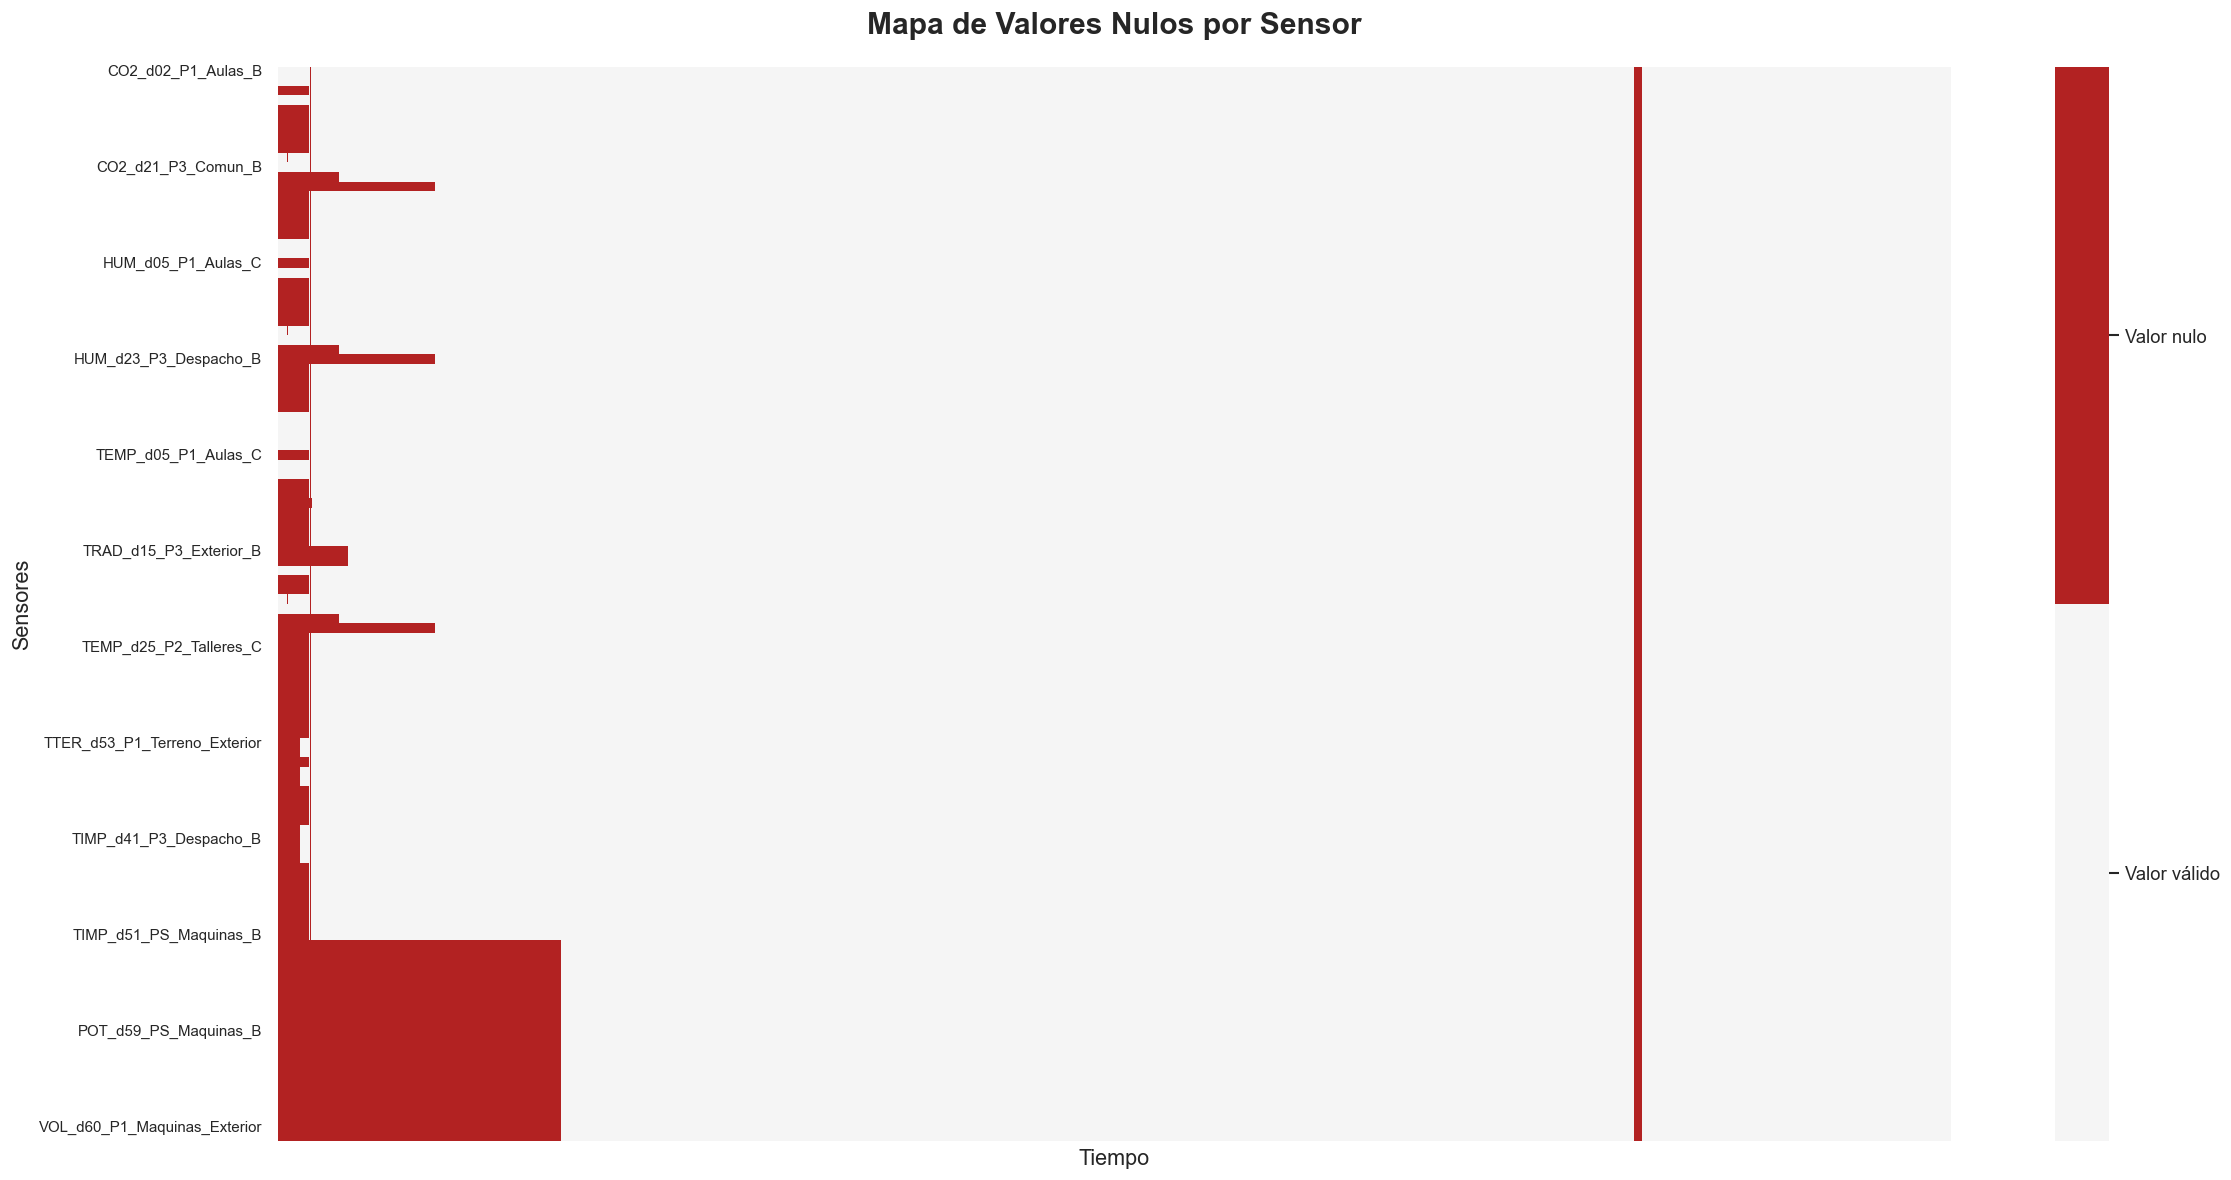

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================
# Muestreo temporal
# =========================
SAMPLE_STEP = max(1, len(df_raw) // 1500)
df_sample = df_raw.iloc[::SAMPLE_STEP]

# Matriz de nulos
null_matrix = df_sample.isna().T

# =========================
# Figura
# =========================
plt.figure(figsize=(20, 10))

ax = sns.heatmap(
    null_matrix,
    cmap=["#F5F5F5", "#B22222"],  # gris claro y rojo elegante
    cbar=True,
    xticklabels=False,
    yticklabels=10,   # muestra solo algunas etiquetas
    linewidths=0,
)

# =========================
# Estética
# =========================
ax.set_title(
    "Mapa de Valores Nulos por Sensor",
    fontsize=18,
    pad=20,
    weight='bold'
)

ax.set_xlabel("Tiempo", fontsize=13)
ax.set_ylabel("Sensores", fontsize=13)

# Mejorar etiquetas Y
ax.tick_params(axis='y', labelsize=9)

# Fondo limpio
ax.set_facecolor('#FAFAFA')

# Barra de color
cbar = ax.collections[0].colorbar
cbar.set_ticks([0.25, 0.75])
cbar.set_ticklabels(['Valor válido', 'Valor nulo'])

plt.tight_layout()

# Guardar
plt.savefig(
    'Graficos/nulos_heatmap_mejorado.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

/var/folders/z4/45j777m57jlc9565gkrw41cr0000gn/T/ipykernel_90151/605403065.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


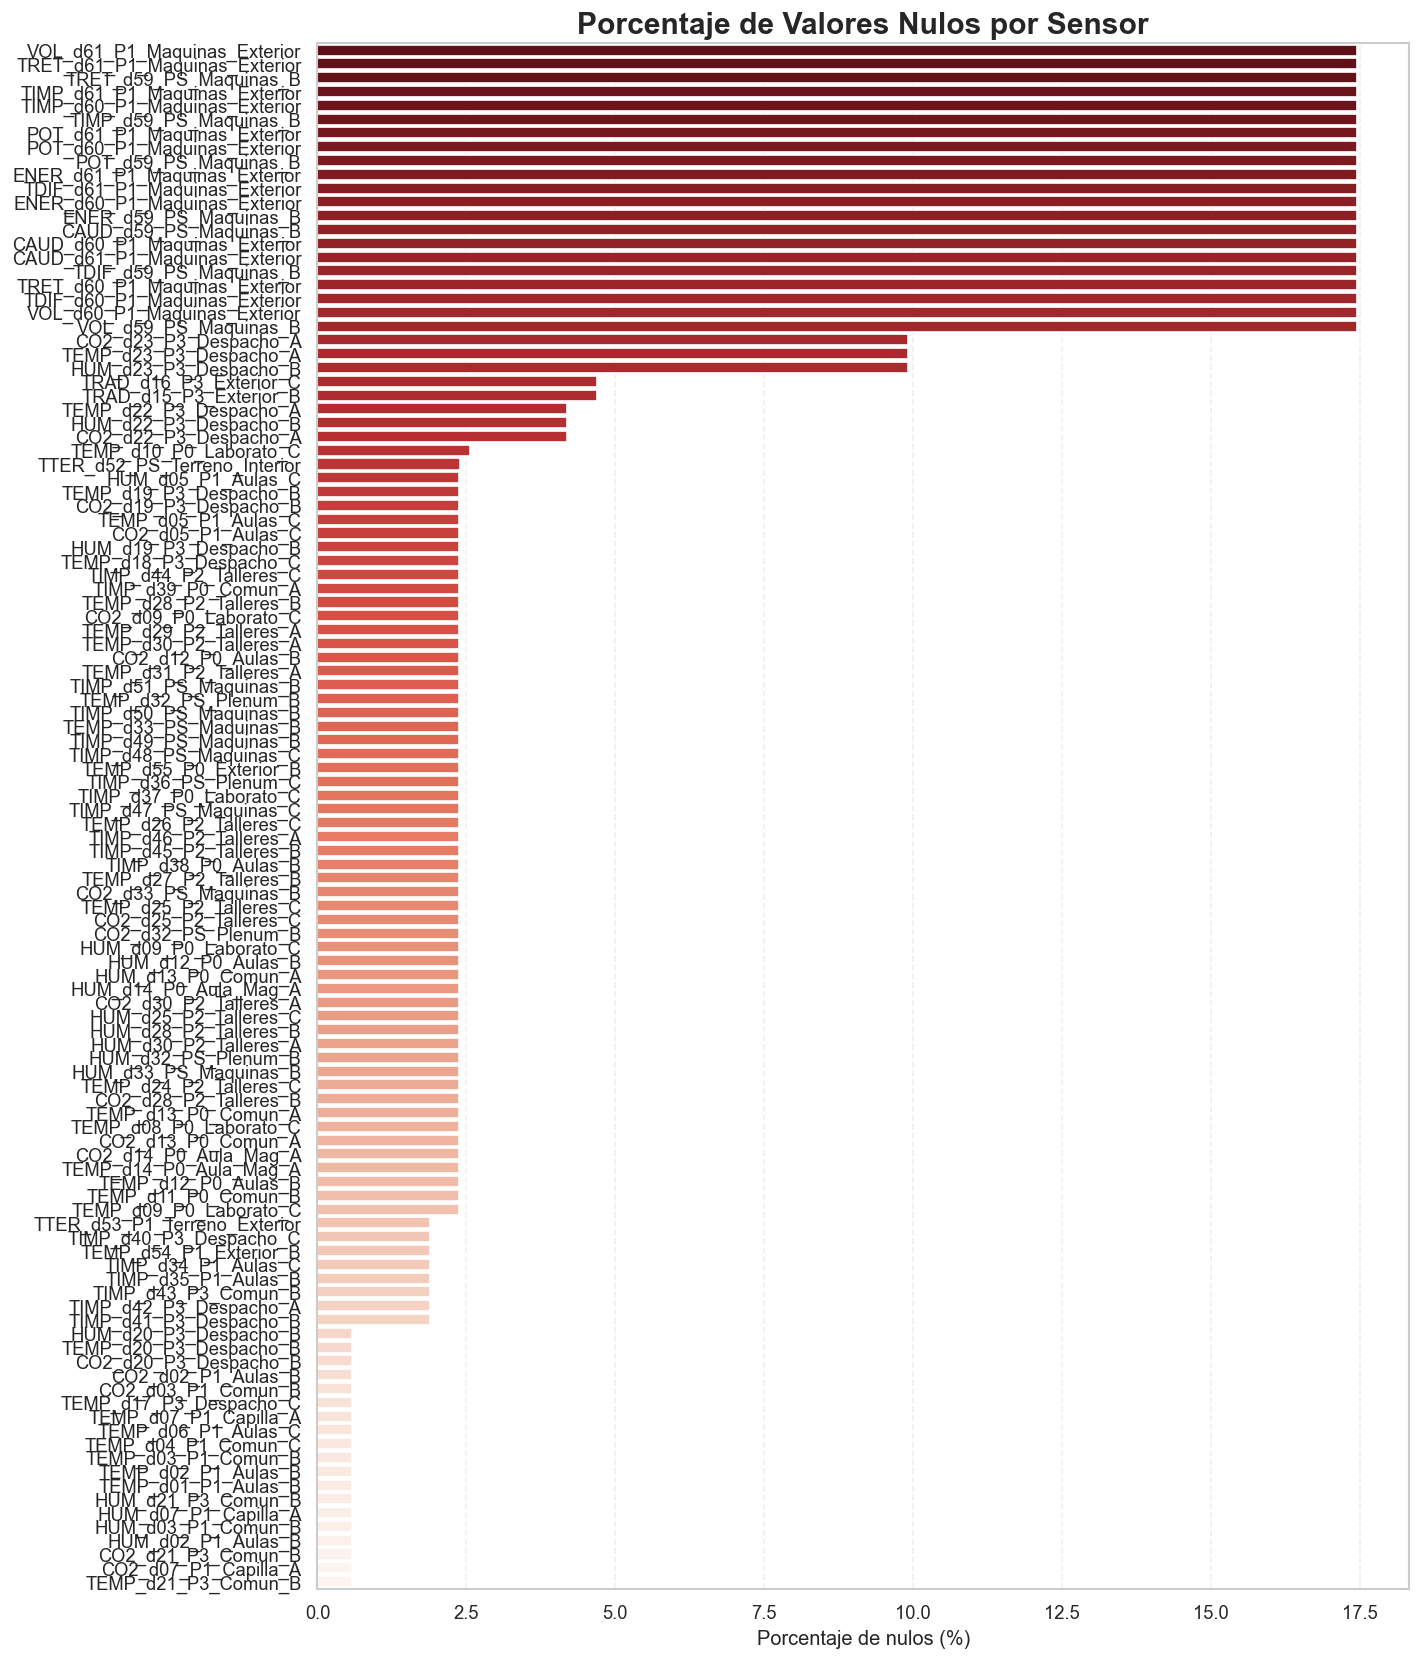

In [57]:
null_percent = df_raw.isna().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 14))

sns.barplot(
    x=null_percent.values,
    y=null_percent.index,
    palette="Reds_r"
)

plt.title(
    "Porcentaje de Valores Nulos por Sensor",
    fontsize=18,
    weight='bold'
)

plt.xlabel("Porcentaje de nulos (%)")
plt.ylabel("")

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.savefig(
    'Graficos/nulos_por_sensor.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [58]:
# SAMPLE_STEP = max(1, len(df_raw) // 2000)
# df_sample   = df_raw.iloc[::SAMPLE_STEP]

# fig, ax = plt.subplots(figsize=(18, 6))
# sns.heatmap(
#     df_sample.isna().T,
#     cbar=False,
#     xticklabels=False,
#     yticklabels=True,
#     cmap='Reds',
#     ax=ax
# )
# ax.set_title('Mapa de valores nulos (filas = sensores, columnas = tiempo)', fontsize=13)
# ax.set_ylabel('')
# plt.tight_layout()
# plt.savefig('Graficos/nulos_heatmap.png', bbox_inches='tight')
# plt.show()

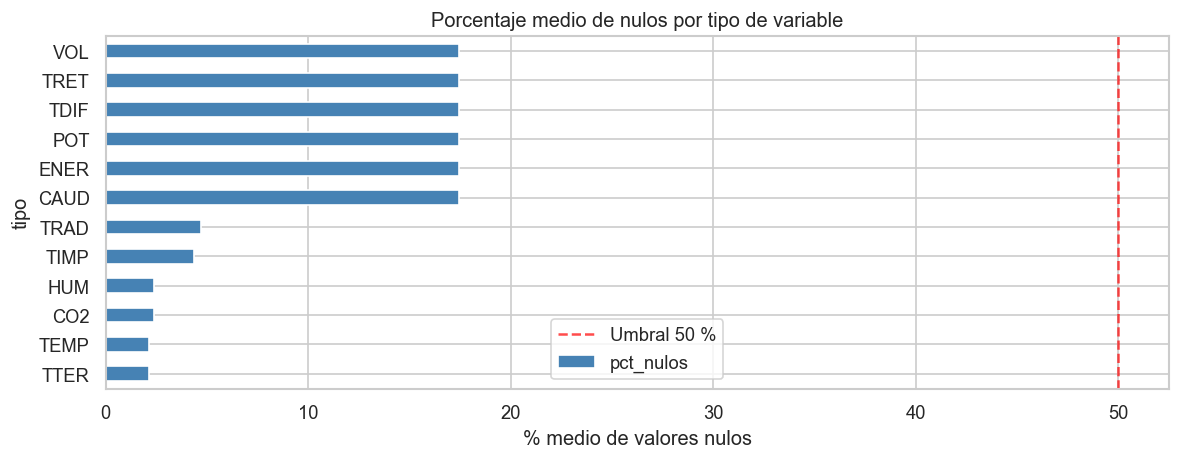

In [59]:
df_nulos_info = nulos_pct.reset_index()
df_nulos_info.columns = ['sensor', 'pct_nulos']

df_nulos_info['tipo'] = df_nulos_info['sensor'].str.split('_').str[0]

fig, ax = plt.subplots(figsize=(10, 4))
df_nulos_info.groupby('tipo')['pct_nulos'].mean().sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('% medio de valores nulos')
ax.set_title('Porcentaje medio de nulos por tipo de variable')
ax.axvline(50, color='red', linestyle='--', alpha=0.7, label='Umbral 50 %')
ax.legend()
plt.tight_layout()
plt.savefig('Graficos/nulos_por_tipo.png', bbox_inches='tight')
plt.show()

## 5. Estrategia de limpieza

### 5.1 Eliminar columnas con demasiados nulos

Usamos un **umbral del 60 %**: si una columna tiene más del 60 % de NaN la descartamos.  

In [60]:
UMBRAL_NULOS = 60.0 

cols_eliminar = nulos_pct[nulos_pct > UMBRAL_NULOS].index.tolist()
print(f'Columnas eliminadas (> {UMBRAL_NULOS} % nulos): {len(cols_eliminar)}')
print('\n'.join(f'  · {c}  ({nulos_pct[c]:.1f} %)' for c in cols_eliminar[:15]))
if len(cols_eliminar) > 15:
    print(f'  ... y {len(cols_eliminar)-15} más')

df_clean = df_raw.drop(columns=cols_eliminar)
print(f'\nShape tras eliminar columnas con muchos nulos: {df_clean.shape}')

Columnas eliminadas (> 60.0 % nulos): 0


Shape tras eliminar columnas con muchos nulos: (90383, 112)


### 5.2 Detección y eliminación de duplicados temporales

In [61]:
n_dupl_clean = df_clean.index.duplicated().sum()
print(f"Timestamps duplicados en df_clean: {n_dupl_clean} " if n_dupl_clean == 0
      else f"Aún hay {n_dupl_clean} duplicados en df_clean")

Timestamps duplicados en df_clean: 0 


### 5.3 Detección de valores físicamente imposibles (outliers duros)

Antes de imputar, se analizan las mediciones que quedan fuera de rangos físicos plausibles y después se sustituyen por `NaN`:
- CO₂: < 300 ppm o > 5000 ppm
- Temperatura interior: < 10 °C o > 35 °C
- Humedad relativa: < 0 % o > 100 %
- Temperatura de impulsión / retorno: < 3 °C o > 80 °C
- Potencia / Energía: < 0

In [62]:
RANGOS_FISICOS = {
    'CO2':  (300, 5000),
    'HUM':  (0,   100),
    'TEMP': (10,   35),
    'TIMP': (3,    80),
    'TRET': (3,    80),
    'TRAD': (-40,  80),
    'TTER': (-20,  40),
    'POT':  (0,  None),  
    'ENER': (0,  None),
    'VOL':  (0,  None),
    'CAUD': (0,  None),
}

outliers_detalle = []
outliers_total = 0

for col in df_clean.columns:
    tipo = col.split('_')[0]
    if tipo not in RANGOS_FISICOS:
        continue
    vmin, vmax = RANGOS_FISICOS[tipo]
    mask = pd.Series(False, index=df_clean.index)
    if vmin is not None:
        mask = mask | (df_clean[col] < vmin)
    if vmax is not None:
        mask = mask | (df_clean[col] > vmax)
    n_out = int(mask.sum())
    if n_out > 0:
        valores_fuera = df_clean.loc[mask, col]
        n_validos = int(df_clean[col].notna().sum())
        outliers_detalle.append({
            'variable': col,
            'tipo': tipo,
            'rango_min': vmin,
            'rango_max': vmax,
            'n_fuera_rango': n_out,
            'pct_fuera_rango': np.nan if n_validos == 0 else 100 * n_out / n_validos,
            'min_observado': valores_fuera.min(),
            'max_observado': valores_fuera.max(),
            'primer_timestamp': valores_fuera.index.min(),
            'ultimo_timestamp': valores_fuera.index.max(),
        })
        df_clean.loc[mask, col] = np.nan
        outliers_total += n_out

outliers_fisicos = pd.DataFrame(outliers_detalle)
if not outliers_fisicos.empty:
    outliers_fisicos = (
        outliers_fisicos
        .sort_values(['tipo', 'n_fuera_rango'], ascending=[True, False])
        .reset_index(drop=True)
    )

print(f'Valores fuera de rango físico reemplazados por NaN: {outliers_total:,}')
display(outliers_fisicos)

Valores fuera de rango físico reemplazados por NaN: 40,156


,variable,tipo,rango_min,rango_max,n_fuera_rango,pct_fuera_rango,min_observado,max_observado,primer_timestamp,ultimo_timestamp
0,CAUD_d59_PS_Maquinas_B,CAUD,0,NaN,955,1.280,-0.927,-0.000,2023-10-24 13:00:00,2025-11-05 08:45:00
1,CAUD_d61_P1_Maquinas_Exterior,CAUD,0,NaN,581,0.779,-26.300,-0.001,2023-10-28 01:45:00,2025-07-11 07:00:00
2,POT_d61_P1_Maquinas_Exterior,POT,0,NaN,5743,7.697,-20.200,-0.000,2023-10-18 14:00:00,2025-09-20 15:00:00
3,POT_d60_P1_Maquinas_Exterior,POT,0,NaN,1425,1.910,-6.800,-0.000,2023-12-17 02:15:00,2025-12-01 05:30:00
4,POT_d59_PS_Maquinas_B,POT,0,NaN,1310,1.756,-8.540,-0.000,2023-10-20 11:15:00,2025-11-13 13:45:00
5,TEMP_d54_P1_Exterior_B,TEMP,10,35.000,13604,15.342,0.040,40.400,2023-07-10 18:15:00,2025-12-08 23:45:00
6,TEMP_d55_P0_Exterior_B,TEMP,10,35.000,12353,13.999,1.320,37.300,2023-08-23 15:45:00,2025-12-08 23:45:00
7,TEMP_d31_P2_Talleres_A,TEMP,10,35.000,566,0.641,9.100,37.800,2023-07-14 18:00:00,2025-08-17 20:15:00
8,TEMP_d26_P2_Talleres_C,TEMP,10,35.000,542,0.614,9.200,37.700,2023-08-18 17:15:00,2025-08-17 20:15:00
9,TEMP_d25_P2_Talleres_C,TEMP,10,35.000,465,0.527,8.550,36.900,2023-08-21 17:45:00,2025-08-15 19:00:00


### 5.4 Imputación de huecos cortos (interpolación lineal)

Para series temporales con resolución de 15 min, los huecos de hasta **2 horas** (8 períodos) se rellenan por interpolación lineal. Los huecos más largos se dejan como NaN para tratamiento posterior o se documentan.

In [63]:
MAX_GAP_PERIODS = 8   

cols_no_interpolar = [c for c in df_clean.columns if c.startswith(('ENER', 'VOL'))]
cols_interpolar    = [c for c in df_clean.columns if c not in cols_no_interpolar]

df_clean[cols_interpolar] = df_clean[cols_interpolar].interpolate(
    method='linear',
    limit=MAX_GAP_PERIODS,
    limit_direction='both',
    axis=0
)

nulos_restantes = df_clean.isna().sum().sum()
print(f'NaN restantes tras interpolación: {nulos_restantes:,}')
print(f'Shape final: {df_clean.shape}')

NaN restantes tras interpolación: 534,997
Shape final: (90383, 112)


### 5.5 Resumen de limpieza

In [64]:
tipos_presentes = pd.Series([c.split('_')[0] for c in df_clean.columns]).value_counts()
print('Sensores por tipo de variable en el dataset limpio:')
print(tipos_presentes.to_string())

print(f'\n--- RESUMEN DE LIMPIEZA ---')
print(f'Filas:    {df_clean.shape[0]:,}')
print(f'Columnas: {df_clean.shape[1]}')
print(f'Periodo:  {df_clean.index.min()} → {df_clean.index.max()}')
print(f'Frecuencia: 15 min')

Sensores por tipo de variable en el dataset limpio:
TEMP    33
TIMP    21
CO2     18
HUM     18
CAUD     3
TDIF     3
ENER     3
POT      3
TRET     3
VOL      3
TRAD     2
TTER     2

--- RESUMEN DE LIMPIEZA ---
Filas:    90,383
Columnas: 112
Periodo:  2023-05-12 12:15:00 → 2025-12-08 23:45:00
Frecuencia: 15 min


## 6. Exportación del dataset limpio

In [65]:
OUT_CSV  = 'datos_limpios/E3Lab_clean.csv'
OUT_META = 'datos_limpios/E3Lab_metadata_sensores.csv'

df_clean.to_csv(OUT_CSV)
df_meta.to_csv(OUT_META, index=False)

print(f'Dataset limpio guardado en:  {OUT_CSV}')
print(f'Metadatos sensores en:       {OUT_META}')

Dataset limpio guardado en:  datos_limpios/E3Lab_clean.csv
Metadatos sensores en:       datos_limpios/E3Lab_metadata_sensores.csv


## 7. Visualización exploratoria rápida

### 7.1 Temperatura interior media diaria por planta

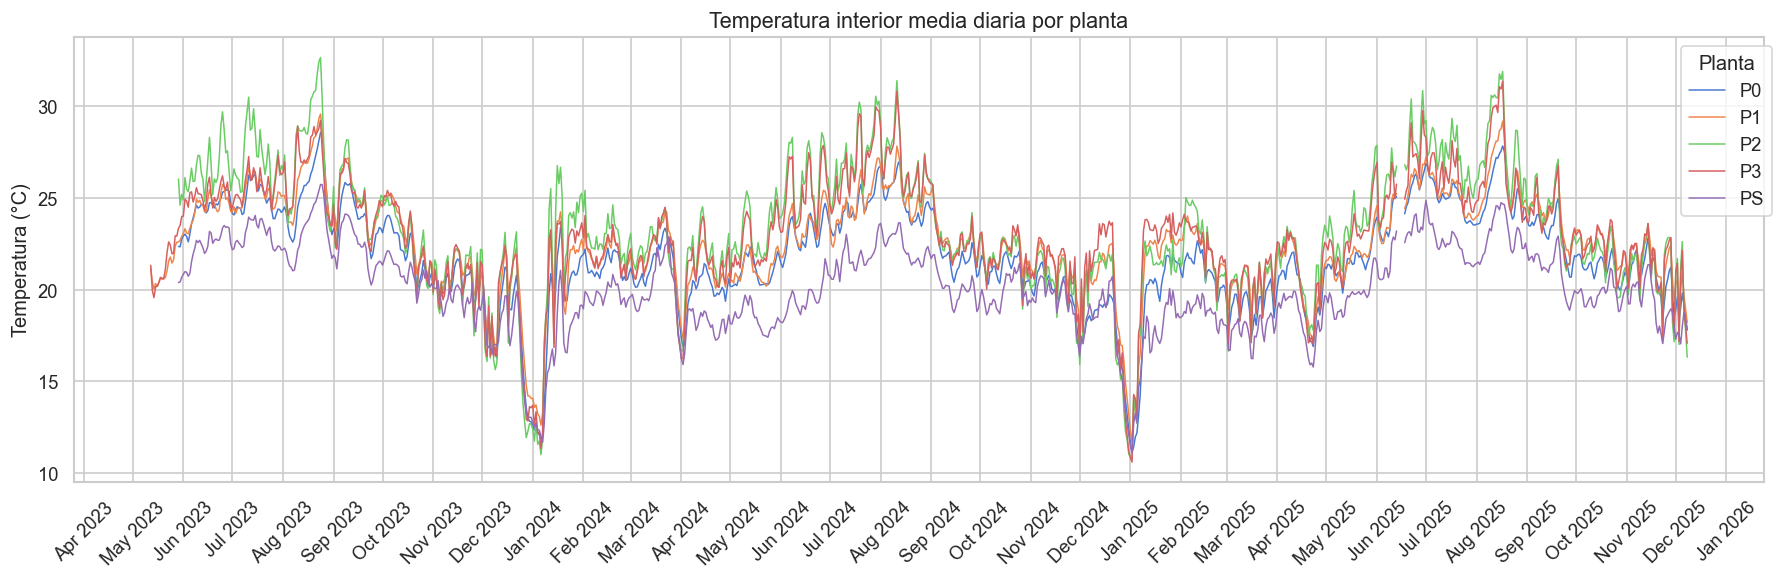

In [66]:
cols_temp_interior = [
    c for c in df_clean.columns
    if c.startswith('TEMP_')
    and 'Exterior' not in c
    and 'Terreno'  not in c
]

plantas = sorted(set(c.split('_')[2] for c in cols_temp_interior))

fig, ax = plt.subplots(figsize=(15, 5))
for planta in plantas:
    cols_pl = [c for c in cols_temp_interior if c.split('_')[2] == planta]
    if cols_pl:
        serie_diaria = df_clean[cols_pl].mean(axis=1).resample('D').mean()
        ax.plot(serie_diaria.index, serie_diaria.values, label=planta, linewidth=0.9)

ax.set_title('Temperatura interior media diaria por planta', fontsize=13)
ax.set_ylabel('Temperatura (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
ax.legend(title='Planta', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('Graficos/temp_interior_plantas.png', bbox_inches='tight')
plt.show()

### 7.2 CO₂ medio diario por uso del espacio

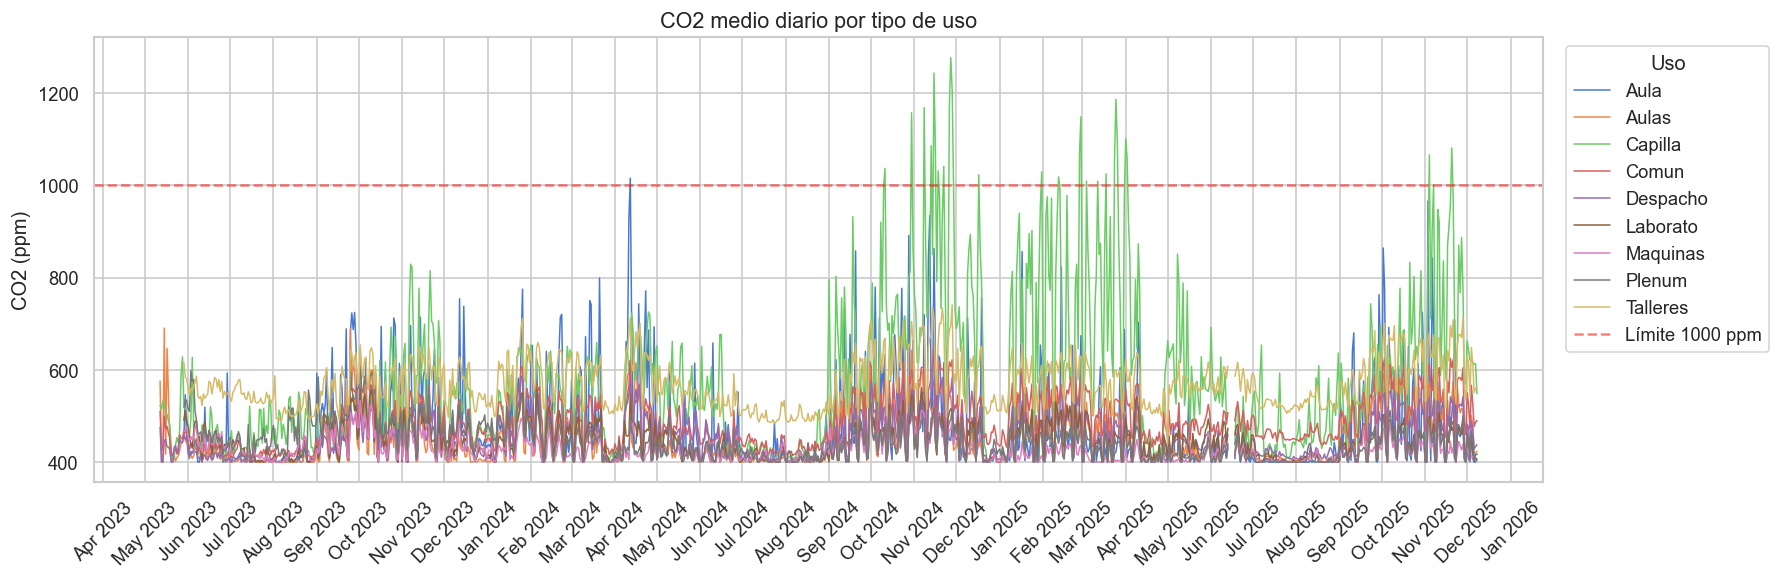

In [67]:
cols_co2 = [c for c in df_clean.columns if c.startswith('CO2_')]
usos_co2 = sorted(set(c.split('_')[3] for c in cols_co2))

fig, ax = plt.subplots(figsize=(15, 5))
for uso in usos_co2:
    cols_uso = [c for c in cols_co2 if c.split('_')[3] == uso]
    if cols_uso:
        serie = df_clean[cols_uso].mean(axis=1).resample('D').mean()
        ax.plot(serie.index, serie.values, label=uso, linewidth=0.9)

ax.axhline(1000, color='red', linestyle='--', alpha=0.5, label='Límite 1000 ppm')
ax.set_title('CO2 medio diario por tipo de uso', fontsize=13)
ax.set_ylabel('CO2 (ppm)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
ax.legend(title='Uso', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('Graficos/co2_por_uso.png', bbox_inches='tight')
plt.show()

### 7.3 Potencia HVAC diaria (si disponible)

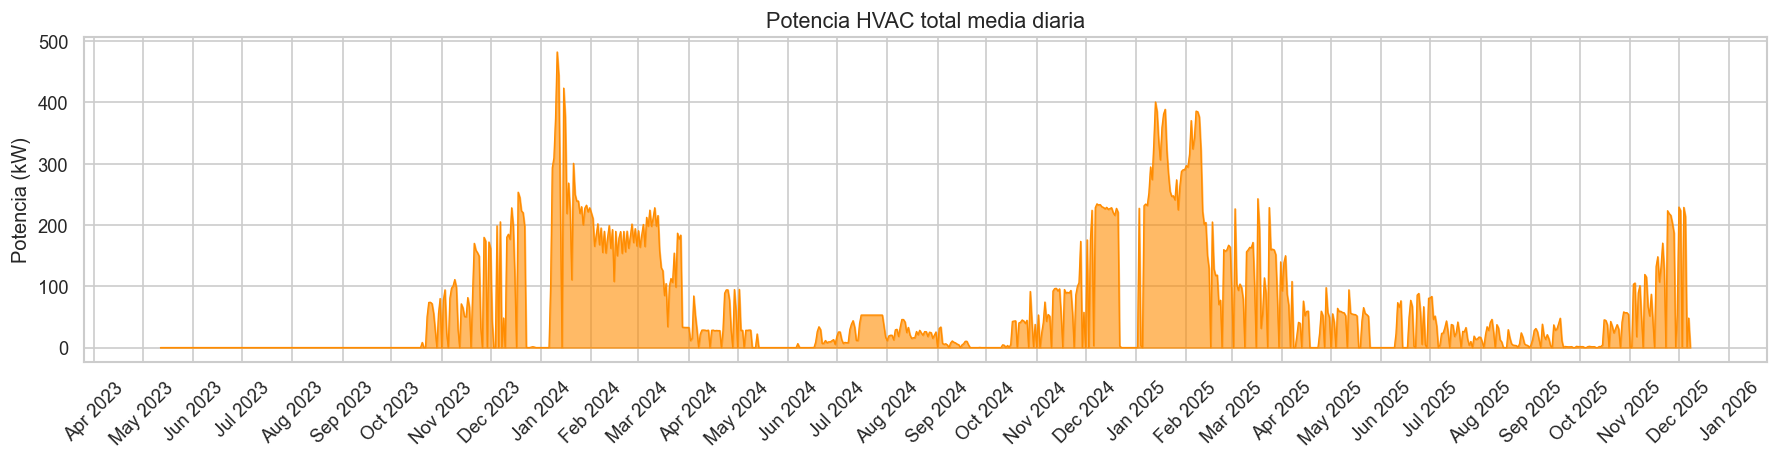

In [68]:
cols_pot = [c for c in df_clean.columns if c.startswith('POT_')]

if cols_pot:
    pot_total_diaria = df_clean[cols_pot].sum(axis=1).resample('D').mean()
    
    fig, ax = plt.subplots(figsize=(15, 4))
    ax.fill_between(pot_total_diaria.index, pot_total_diaria.values, alpha=0.6, color='darkorange')
    ax.plot(pot_total_diaria.index, pot_total_diaria.values, color='darkorange', linewidth=0.8)
    ax.set_title('Potencia HVAC total media diaria', fontsize=13)
    ax.set_ylabel('Potencia (kW)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('Graficos/potencia_hvac_diaria.png', bbox_inches='tight')
    plt.show()
else:
    print('No hay columnas de Potencia en el dataset limpio (umbral de nulos demasiado estricto para el primer periodo).')
    print('Considera reducir UMBRAL_NULOS o gestionar el primer CSV por separado.')

### 7.4 Matriz de correlación entre variables clave

/var/folders/z4/45j777m57jlc9565gkrw41cr0000gn/T/ipykernel_90151/2777601662.py:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  corr_df = df_clean[cols_corr].resample('H').mean().corr()


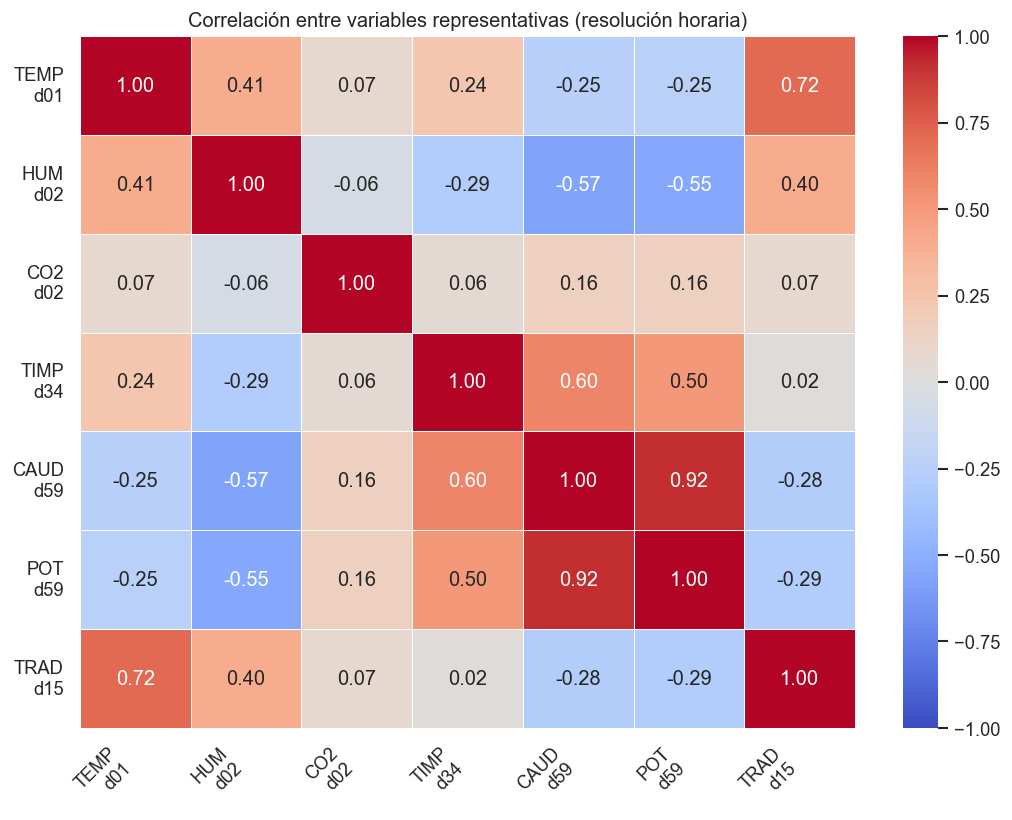

In [69]:
def primera_col_tipo(prefijo):
    cols = [c for c in df_clean.columns if c.startswith(prefijo)]
    return cols[0] if cols else None

cols_corr = [
    primera_col_tipo('TEMP_'),
    primera_col_tipo('HUM_'),
    primera_col_tipo('CO2_'),
    primera_col_tipo('TIMP_'),
    primera_col_tipo('CAUD_'),
    primera_col_tipo('POT_'),
    primera_col_tipo('TRAD_'),
]
cols_corr = [c for c in cols_corr if c is not None]

corr_df = df_clean[cols_corr].resample('H').mean().corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_df,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Correlación entre variables representativas (resolución horaria)', fontsize=12)
labels = [c.split('_')[0] + '\n' + c.split('_')[1] for c in cols_corr]
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels, rotation=0)
plt.tight_layout()
plt.savefig('Graficos/correlacion_variables.png', bbox_inches='tight')
plt.show()

## 8. Análisis detallado por planta

Para cada planta (P0, P1, P2, P3, PS) se generan 4 gráficas:
- **Serie temporal diaria** — evolución de todos los sensores de temperatura
- **Boxplot mensual** — distribución mes a mes
- **Comparativa por zona** (A, B, C) — media diaria de cada zona
- **Perfil horario** (heatmap día × hora)

Además se incluyen secciones equivalentes para **humedad**, **CO₂** e **impulsión**.

In [70]:
PLANTAS = ['P0', 'P1', 'P2', 'P3', 'PS']
DIAS    = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
COLORES_ZONA = {'A': '#e63946', 'B': '#457b9d', 'C': '#2a9d8f',
                'Interior': '#f4a261', 'Exterior': '#6d6875'}

def cols_por_planta(prefijo, planta):
    return [c for c in df_clean.columns
            if c.startswith(prefijo) and c.split('_')[2] == planta]

def zona_de(col):
    parts = col.split('_')
    return parts[4] if len(parts) > 4 else 'N/A'

def serie_diaria(cols):
    return df_clean[cols].mean(axis=1).resample('D').mean()

def serie_horaria(cols):
    return df_clean[cols].mean(axis=1)

print('Helpers definidos')

Helpers definidos


### 8.1 Temperatura — Serie temporal diaria por planta

In [71]:
for planta in PLANTAS:
    cols = [c for c in df_clean.columns
            if c.startswith('TEMP_') and c.split('_')[2] == planta
            and 'Exterior' not in c and 'Terreno' not in c]
    if not cols:
        continue

    fig, ax = plt.subplots(figsize=(15, 4))
    for col in cols:
        zona = zona_de(col)
        color = COLORES_ZONA.get(zona, None)
        ax.plot(df_clean[col].resample('D').mean(), linewidth=0.8,
                alpha=0.75, color=color, label=f'{col.split("_")[1]} ({zona})')

    ax.set_title(f'Temperatura interior — {planta} — serie diaria por sensor', fontsize=12)
    ax.set_ylabel('Temperatura (°C)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=45)
    ax.legend(fontsize=7, ncol=3, bbox_to_anchor=(1.01, 1))
    plt.tight_layout()
    plt.savefig(f'Graficos/temp_{planta}_serie_diaria.png', bbox_inches='tight')
    plt.close()
    print(f'temp_{planta}_serie_diaria.png')

temp_P0_serie_diaria.png
temp_P1_serie_diaria.png
temp_P2_serie_diaria.png
temp_P3_serie_diaria.png
temp_PS_serie_diaria.png


### 8.2 Temperatura — Boxplot mensual por planta

In [72]:
for planta in PLANTAS:
    cols = [c for c in df_clean.columns
            if c.startswith('TEMP_') and c.split('_')[2] == planta
            and 'Exterior' not in c and 'Terreno' not in c]
    if not cols:
        continue

    serie = df_clean[cols].mean(axis=1).resample('h').mean()
    df_bp = pd.DataFrame({
        'temp': serie.values,
        'mes':  serie.index.strftime('%Y-%m')
    })
    meses = sorted(df_bp['mes'].unique())

    fig, ax = plt.subplots(figsize=(14, 4))
    sns.boxplot(data=df_bp, x='mes', y='temp', order=meses,
                color='steelblue',
                flierprops=dict(marker='.', alpha=0.3, markersize=2), ax=ax)
    ax.set_title(f'Temperatura interior — {planta} — distribución mensual', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Temperatura (°C)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'Graficos/temp_{planta}_boxplot_mensual.png', bbox_inches='tight')
    plt.close()
    print(f'temp_{planta}_boxplot_mensual.png')

temp_P0_boxplot_mensual.png
temp_P1_boxplot_mensual.png
temp_P2_boxplot_mensual.png
temp_P3_boxplot_mensual.png
temp_PS_boxplot_mensual.png


### 8.3 Temperatura — Comparativa por zona (A, B, C) dentro de cada planta

In [73]:
for planta in PLANTAS:
    cols = [c for c in df_clean.columns
            if c.startswith('TEMP_') and c.split('_')[2] == planta
            and 'Exterior' not in c and 'Terreno' not in c]
    if not cols:
        continue

    zonas = sorted(set(zona_de(c) for c in cols))
    fig, ax = plt.subplots(figsize=(15, 4))
    for zona in zonas:
        cols_z = [c for c in cols if zona_de(c) == zona]
        serie  = serie_diaria(cols_z)
        color  = COLORES_ZONA.get(zona, 'gray')
        ax.plot(serie.index, serie.values, label=f'Zona {zona}',
                color=color, linewidth=1.4)
        # banda de dispersión entre sensores de la misma zona
        if len(cols_z) > 1:
            s_min = df_clean[cols_z].min(axis=1).resample('D').mean()
            s_max = df_clean[cols_z].max(axis=1).resample('D').mean()
            ax.fill_between(serie.index, s_min, s_max, alpha=0.12, color=color)

    ax.set_title(f'Temperatura interior — {planta} — comparativa por zona', fontsize=12)
    ax.set_ylabel('Temperatura (°C)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=45)
    ax.legend(title='Zona')
    plt.tight_layout()
    plt.savefig(f'Graficos/temp_{planta}_zonas.png', bbox_inches='tight')
    plt.close()
    print(f'temp_{planta}_zonas.png')

temp_P0_zonas.png
temp_P1_zonas.png
temp_P2_zonas.png
temp_P3_zonas.png
temp_PS_zonas.png


### 8.4 Temperatura — Perfil horario (heatmap día × hora) por planta

In [74]:
for planta in PLANTAS:
    cols = [c for c in df_clean.columns
            if c.startswith('TEMP_') and c.split('_')[2] == planta
            and 'Exterior' not in c and 'Terreno' not in c]
    if not cols:
        continue

    media = df_clean[cols].mean(axis=1)
    df_hm = pd.DataFrame({
        'temp':       media.values,
        'hora':       media.index.hour,
        'dia_semana': media.index.dayofweek
    })
    pivot = df_hm.groupby(['dia_semana', 'hora'])['temp'].mean().unstack()

    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(pivot, cmap='RdYlBu_r', ax=ax,
                xticklabels=range(0, 24), yticklabels=DIAS,
                cbar_kws={'label': '°C'}, linewidths=0.15)
    ax.set_title(f'Temperatura interior — {planta} — perfil horario (°C)', fontsize=12)
    ax.set_xlabel('Hora del día')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig(f'Graficos/temp_{planta}_perfil_horario.png', bbox_inches='tight')
    plt.close()
    print(f'temp_{planta}_perfil_horario.png')

temp_P0_perfil_horario.png
temp_P1_perfil_horario.png
temp_P2_perfil_horario.png
temp_P3_perfil_horario.png
temp_PS_perfil_horario.png


### 8.5 Humedad relativa — Serie diaria y comparativa por zona

In [75]:
for planta in PLANTAS:
    cols = [c for c in df_clean.columns
            if c.startswith('HUM_') and c.split('_')[2] == planta]
    if not cols:
        continue

    zonas = sorted(set(zona_de(c) for c in cols))
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # — izquierda: serie por sensor —
    for col in cols:
        zona  = zona_de(col)
        color = COLORES_ZONA.get(zona, None)
        axes[0].plot(df_clean[col].resample('D').mean(), linewidth=0.8,
                     alpha=0.75, color=color, label=f'{col.split("_")[1]} ({zona})')
    axes[0].axhspan(30, 60, alpha=0.08, color='green', label='Rango confort')
    axes[0].set_title(f'Humedad — {planta} — serie diaria')
    axes[0].set_ylabel('Humedad relativa (%)')
    axes[0].set_ylim(0, 100)
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[0].xaxis.set_major_locator(mdates.MonthLocator())
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend(fontsize=7, ncol=2)

    # — derecha: comparativa por zona —
    for zona in zonas:
        cols_z = [c for c in cols if zona_de(c) == zona]
        serie  = serie_diaria(cols_z)
        color  = COLORES_ZONA.get(zona, 'gray')
        axes[1].plot(serie.index, serie.values, label=f'Zona {zona}',
                     color=color, linewidth=1.4)
        if len(cols_z) > 1:
            s_min = df_clean[cols_z].min(axis=1).resample('D').mean()
            s_max = df_clean[cols_z].max(axis=1).resample('D').mean()
            axes[1].fill_between(serie.index, s_min, s_max, alpha=0.12, color=color)
    axes[1].axhspan(30, 60, alpha=0.08, color='green', label='Rango confort')
    axes[1].set_title(f'Humedad — {planta} — por zona')
    axes[1].set_ylim(0, 100)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[1].xaxis.set_major_locator(mdates.MonthLocator())
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(title='Zona')

    plt.suptitle(f'Humedad relativa — {planta}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'Graficos/hum_{planta}_serie_zonas.png', bbox_inches='tight')
    plt.close()
    print(f'hum_{planta}_serie_zonas.png')

hum_P0_serie_zonas.png
hum_P1_serie_zonas.png
hum_P2_serie_zonas.png
hum_P3_serie_zonas.png
hum_PS_serie_zonas.png


### 8.6 CO₂ — Serie diaria y comparativa por zona

In [76]:
for planta in PLANTAS:
    cols = [c for c in df_clean.columns
            if c.startswith('CO2_') and c.split('_')[2] == planta]
    if not cols:
        continue

    zonas = sorted(set(zona_de(c) for c in cols))
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # — izquierda: serie por sensor —
    for col in cols:
        zona  = zona_de(col)
        color = COLORES_ZONA.get(zona, None)
        axes[0].plot(df_clean[col].resample('D').mean(), linewidth=0.8,
                     alpha=0.75, color=color, label=f'{col.split("_")[1]} ({zona})')
    axes[0].axhline(1000, color='red', linestyle='--', alpha=0.6, linewidth=1, label='1000 ppm')
    axes[0].set_title(f'CO₂ — {planta} — serie diaria')
    axes[0].set_ylabel('CO₂ (ppm)')
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[0].xaxis.set_major_locator(mdates.MonthLocator())
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend(fontsize=7, ncol=2)

    # — derecha: comparativa por zona —
    for zona in zonas:
        cols_z = [c for c in cols if zona_de(c) == zona]
        serie  = serie_diaria(cols_z)
        color  = COLORES_ZONA.get(zona, 'gray')
        axes[1].plot(serie.index, serie.values, label=f'Zona {zona}',
                     color=color, linewidth=1.4)
        if len(cols_z) > 1:
            s_min = df_clean[cols_z].min(axis=1).resample('D').mean()
            s_max = df_clean[cols_z].max(axis=1).resample('D').mean()
            axes[1].fill_between(serie.index, s_min, s_max, alpha=0.12, color=color)
    axes[1].axhline(1000, color='red', linestyle='--', alpha=0.6, linewidth=1, label='1000 ppm')
    axes[1].set_title(f'CO₂ — {planta} — por zona')
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[1].xaxis.set_major_locator(mdates.MonthLocator())
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(title='Zona')

    plt.suptitle(f'CO₂ — {planta}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'Graficos/co2_{planta}_serie_zonas.png', bbox_inches='tight')
    plt.close()
    print(f'co2_{planta}_serie_zonas.png')

/var/folders/z4/45j777m57jlc9565gkrw41cr0000gn/T/ipykernel_90151/282722554.py:43: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/z4/45j777m57jlc9565gkrw41cr0000gn/T/ipykernel_90151/282722554.py:44: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(f'Graficos/co2_{planta}_serie_zonas.png', bbox_inches='tight')


co2_P0_serie_zonas.png


/var/folders/z4/45j777m57jlc9565gkrw41cr0000gn/T/ipykernel_90151/282722554.py:43: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/z4/45j777m57jlc9565gkrw41cr0000gn/T/ipykernel_90151/282722554.py:44: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(f'Graficos/co2_{planta}_serie_zonas.png', bbox_inches='tight')


co2_P1_serie_zonas.png


/var/folders/z4/45j777m57jlc9565gkrw41cr0000gn/T/ipykernel_90151/282722554.py:43: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/z4/45j777m57jlc9565gkrw41cr0000gn/T/ipykernel_90151/282722554.py:44: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(f'Graficos/co2_{planta}_serie_zonas.png', bbox_inches='tight')


...

/var/folders/z4/45j777m57jlc9565gkrw41cr0000gn/T/ipykernel_90151/282722554.py:43: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/z4/45j777m57jlc9565gkrw41cr0000gn/T/ipykernel_90151/282722554.py:44: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(f'Graficos/co2_{planta}_serie_zonas.png', bbox_inches='tight')


co2_P3_serie_zonas.png


/var/folders/z4/45j777m57jlc9565gkrw41cr0000gn/T/ipykernel_90151/282722554.py:43: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


co2_PS_serie_zonas.png


/var/folders/z4/45j777m57jlc9565gkrw41cr0000gn/T/ipykernel_90151/282722554.py:44: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(f'Graficos/co2_{planta}_serie_zonas.png', bbox_inches='tight')


### 8.7 Temperatura de impulsión — Serie diaria por zona

In [77]:
for planta in PLANTAS:
    cols_imp = [c for c in df_clean.columns
                if c.startswith('TIMP_') and c.split('_')[2] == planta]
    cols_ret = [c for c in df_clean.columns
                if c.startswith('TRET_') and c.split('_')[2] == planta]
    if not cols_imp:
        continue

    zonas_imp = sorted(set(zona_de(c) for c in cols_imp))
    fig, ax = plt.subplots(figsize=(15, 4))

    for zona in zonas_imp:
        cols_z = [c for c in cols_imp if zona_de(c) == zona]
        serie  = serie_diaria(cols_z)
        color  = COLORES_ZONA.get(zona, 'gray')
        ax.plot(serie.index, serie.values, label=f'Imp. Zona {zona}',
                color=color, linewidth=1.3, linestyle='-')

    if cols_ret:
        zonas_ret = sorted(set(zona_de(c) for c in cols_ret))
        for zona in zonas_ret:
            cols_z = [c for c in cols_ret if zona_de(c) == zona]
            serie  = serie_diaria(cols_z)
            color  = COLORES_ZONA.get(zona, 'gray')
            ax.plot(serie.index, serie.values, label=f'Ret. Zona {zona}',
                    color=color, linewidth=1.0, linestyle='--', alpha=0.7)

    ax.set_title(f'T. Impulsión (y Retorno si disponible) — {planta} — por zona', fontsize=12)
    ax.set_ylabel('Temperatura (°C)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=45)
    ax.legend(fontsize=8, ncol=3, bbox_to_anchor=(1.01, 1))
    plt.tight_layout()
    plt.savefig(f'Graficos/timp_{planta}_zonas.png', bbox_inches='tight')
    plt.close()
    print(f'timp_{planta}_zonas.png')

timp_P0_zonas.png
timp_P1_zonas.png
timp_P2_zonas.png
timp_P3_zonas.png
timp_PS_zonas.png


## 9. Segmentación por estación del año

Dividimos el dataset en las cuatro estaciones meteorológicas del hemisferio norte:

| Estación | Meses | Código |
|---|---|---|
| Primavera | Marzo, Abril, Mayo | `primavera` |
| Verano | Junio, Julio, Agosto | `verano` |
| Otoño | Septiembre, Octubre, Noviembre | `otoño` |
| Invierno | Diciembre, Enero, Febrero | `invierno` |

Para cada estación se generan:
1. **Estadísticas descriptivas** (media, std, min, max, percentiles)
2. **Exportación** de subsets CSV (`E3Lab_clean_<estacion>.csv`)
3. **Gráficas comparativas** entre estaciones de las variables clave

### 9.1 Definición de estaciones y creación de subsets

In [78]:
def mes_a_estacion(mes):
    if mes in [3, 4, 5]:   return 'primavera'
    if mes in [6, 7, 8]:   return 'verano'
    if mes in [9, 10, 11]: return 'otoño'
    return 'invierno'

ESTACIONES = ['invierno', 'primavera', 'verano', 'otoño']
COLORES_EST = {
    'invierno':  '#4e9af1',
    'primavera': '#57cc99',
    'verano':    '#f4a261',
    'otoño':     '#c77dff',
}


# Columna auxiliar de estación
df_clean['estacion'] = df_clean.index.month.map(mes_a_estacion)

# Subsets por estación
dfs_est = {est: df_clean[df_clean['estacion'] == est].drop(columns='estacion')
           for est in ESTACIONES}

print('Registros por estación (intervalos de 15 min):')
for est, df_e in dfs_est.items():
    horas = len(df_e) * 15 / 60
    print(f'   {est:<12} {len(df_e):>7,} registros  ({horas:,.0f} h  |  {horas/24:.0f} días)')

# Quitar columna auxiliar del df principal
df_clean = df_clean.drop(columns='estacion')

Registros por estación (intervalos de 15 min):
   invierno      18,144 registros  (4,536 h  |  189 días)
   primavera     19,535 registros  (4,884 h  |  203 días)
   verano        26,496 registros  (6,624 h  |  276 días)
   otoño         26,208 registros  (6,552 h  |  273 días)


/var/folders/z4/45j777m57jlc9565gkrw41cr0000gn/T/ipykernel_90151/1654620630.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean['estacion'] = df_clean.index.month.map(mes_a_estacion)


### 9.2 Estadísticas descriptivas por estación

In [79]:
# Variables representativas para el resumen
def primera(prefijo):
    cols = [c for c in df_clean.columns if c.startswith(prefijo)]
    return cols[0] if cols else None

vars_resumen = {
    'Temp. interior':  [c for c in df_clean.columns if c.startswith('TEMP_')
                        and 'Exterior' not in c and 'Terreno' not in c],
    'Temp. exterior':  [c for c in df_clean.columns if 'Exterior' in c and c.startswith('TEMP_')],
    'Humedad':         [c for c in df_clean.columns if c.startswith('HUM_')],
    'CO₂':             [c for c in df_clean.columns if c.startswith('CO2_')],
    'T. Impulsión':    [c for c in df_clean.columns if c.startswith('TIMP_')],
    'Potencia HVAC':   [c for c in df_clean.columns if c.startswith('POT_')],
}

filas = []
for est in ESTACIONES:
    df_e = dfs_est[est]
    fila = {'Estación': f' {est}'}
    for nombre, cols in vars_resumen.items():
        cols_ok = [c for c in cols if c in df_e.columns]
        if cols_ok:
            serie = df_e[cols_ok].mean(axis=1).dropna()
            fila[f'{nombre} — media'] = round(serie.mean(), 2)
            fila[f'{nombre} — std']   = round(serie.std(),  2)
            fila[f'{nombre} — min']   = round(serie.min(),  2)
            fila[f'{nombre} — max']   = round(serie.max(),  2)
        else:
            for suf in ['media','std','min','max']:
                fila[f'{nombre} — {suf}'] = None
    filas.append(fila)

df_stats = pd.DataFrame(filas).set_index('Estación')
# Mostrar transpuesto para mejor lectura
df_stats.T

Estación,invierno,primavera,verano,otoño
Temp. interior — media,19.950,21.140,25.560,22.100
Temp. interior — std,3.300,1.850,1.800,1.940
Temp. interior — min,10.660,14.840,21.040,16.310
Temp. interior — max,25.170,27.810,31.630,28.630
Temp. exterior — media,12.400,15.290,22.910,17.360
Temp. exterior — std,2.350,3.860,4.110,4.300
Temp. exterior — min,10.000,10.000,10.550,10.000
Temp. exterior — max,22.150,30.350,35.000,32.650
Humedad — media,45.640,47.980,55.490,54.600
Humedad — std,8.760,5.270,4.220,5.710


### 9.3 Exportación de subsets CSV por estación

In [80]:
import os
os.makedirs('Datos_por_estacion', exist_ok=True)

for est, df_e in dfs_est.items():
    path = f'Datos_por_estacion/E3Lab_clean_{est}.csv'
    df_e.to_csv(path)
    size_mb = os.path.getsize(path) / 1e6
    print(f'   {path}  -  {len(df_e):,} filas  ({size_mb:.1f} MB)')

print('\nCSVs por estación guardados en Datos_por_estacion/')

   Datos_por_estacion/E3Lab_clean_invierno.csv  -  18,144 filas  (11.0 MB)
   Datos_por_estacion/E3Lab_clean_primavera.csv  -  19,535 filas  (11.3 MB)
   Datos_por_estacion/E3Lab_clean_verano.csv  -  26,496 filas  (15.0 MB)
   Datos_por_estacion/E3Lab_clean_otoño.csv  -  26,208 filas  (15.5 MB)

CSVs por estación guardados en Datos_por_estacion/


### 9.4 Comparativa entre estaciones — Temperatura interior

/var/folders/z4/45j777m57jlc9565gkrw41cr0000gn/T/ipykernel_90151/2689143606.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bp_est, x='estacion', y='temp', order=ESTACIONES,
/var/folders/z4/45j777m57jlc9565gkrw41cr0000gn/T/ipykernel_90151/2689143606.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([f'{COLORES_EST[e]}\n{e}' for e in ESTACIONES])
/var/folders/z4/45j777m57jlc9565gkrw41cr0000gn/T/ipykernel_90151/2689143606.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_bp_est, x='estacion', y='temp', order=ESTACIONES,
/var/folders/z4/45j777m57jlc9565gkrw

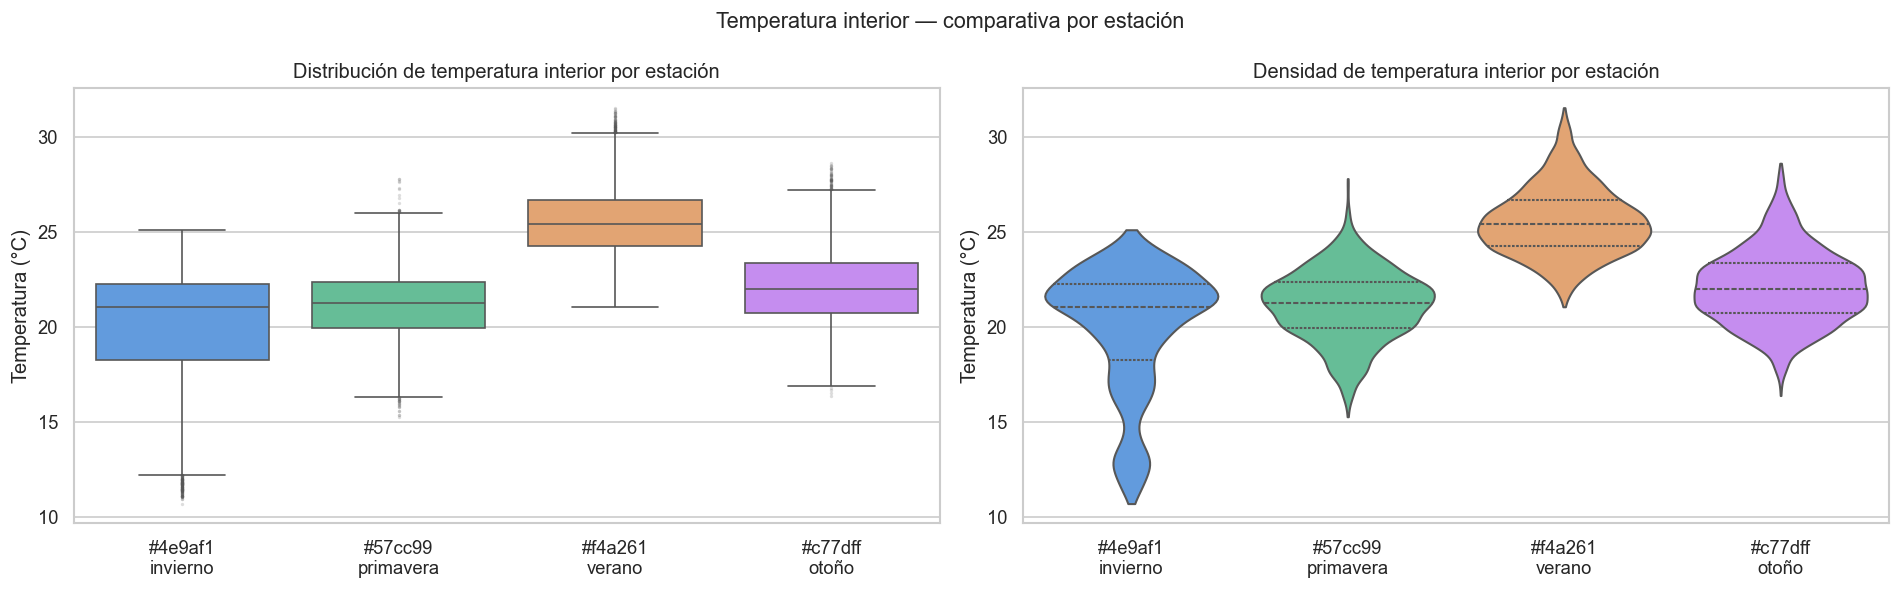

est_temp_interior_comparativa.png


In [81]:
cols_ti = [c for c in df_clean.columns if c.startswith('TEMP_')
           and 'Exterior' not in c and 'Terreno' not in c]

df_bp_est = pd.concat([
    pd.DataFrame({
        'temp':     dfs_est[est][cols_ti].mean(axis=1).resample('h').mean().values,
        'estacion': est,
        'timestamp': dfs_est[est][cols_ti].mean(axis=1).resample('h').mean().index
    }) for est in ESTACIONES
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# — Boxplot —
sns.boxplot(data=df_bp_est, x='estacion', y='temp', order=ESTACIONES,
            palette=COLORES_EST, ax=axes[0],
            flierprops=dict(marker='.', alpha=0.2, markersize=2))
axes[0].set_title('Distribución de temperatura interior por estación', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].set_xticklabels([f'{COLORES_EST[e]}\n{e}' for e in ESTACIONES])

# — Violinplot —
sns.violinplot(data=df_bp_est, x='estacion', y='temp', order=ESTACIONES,
               palette=COLORES_EST, ax=axes[1], inner='quartile', cut=0)
axes[1].set_title('Densidad de temperatura interior por estación', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Temperatura (°C)')
axes[1].set_xticklabels([f'{COLORES_EST[e]}\n{e}' for e in ESTACIONES])

plt.suptitle('Temperatura interior — comparativa por estación', fontsize=13)
plt.tight_layout()
plt.savefig('Graficos/est_temp_interior_comparativa.png', bbox_inches='tight')
plt.show()
print('est_temp_interior_comparativa.png')

### 9.6 Potencia HVAC y CO2 por estación

/var/folders/z4/45j777m57jlc9565gkrw41cr0000gn/T/ipykernel_90151/1527232353.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pot_bp, x='estacion', y='valor', order=ESTACIONES,
/var/folders/z4/45j777m57jlc9565gkrw41cr0000gn/T/ipykernel_90151/1527232353.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([f'{COLORES_EST[e]}\n{e}' for e in ESTACIONES])
/var/folders/z4/45j777m57jlc9565gkrw41cr0000gn/T/ipykernel_90151/1527232353.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_co2_bp, x='estacion', y='valor', order=ESTACIONES,
/var/folders/z4/45j777m57jlc9565gkrw4

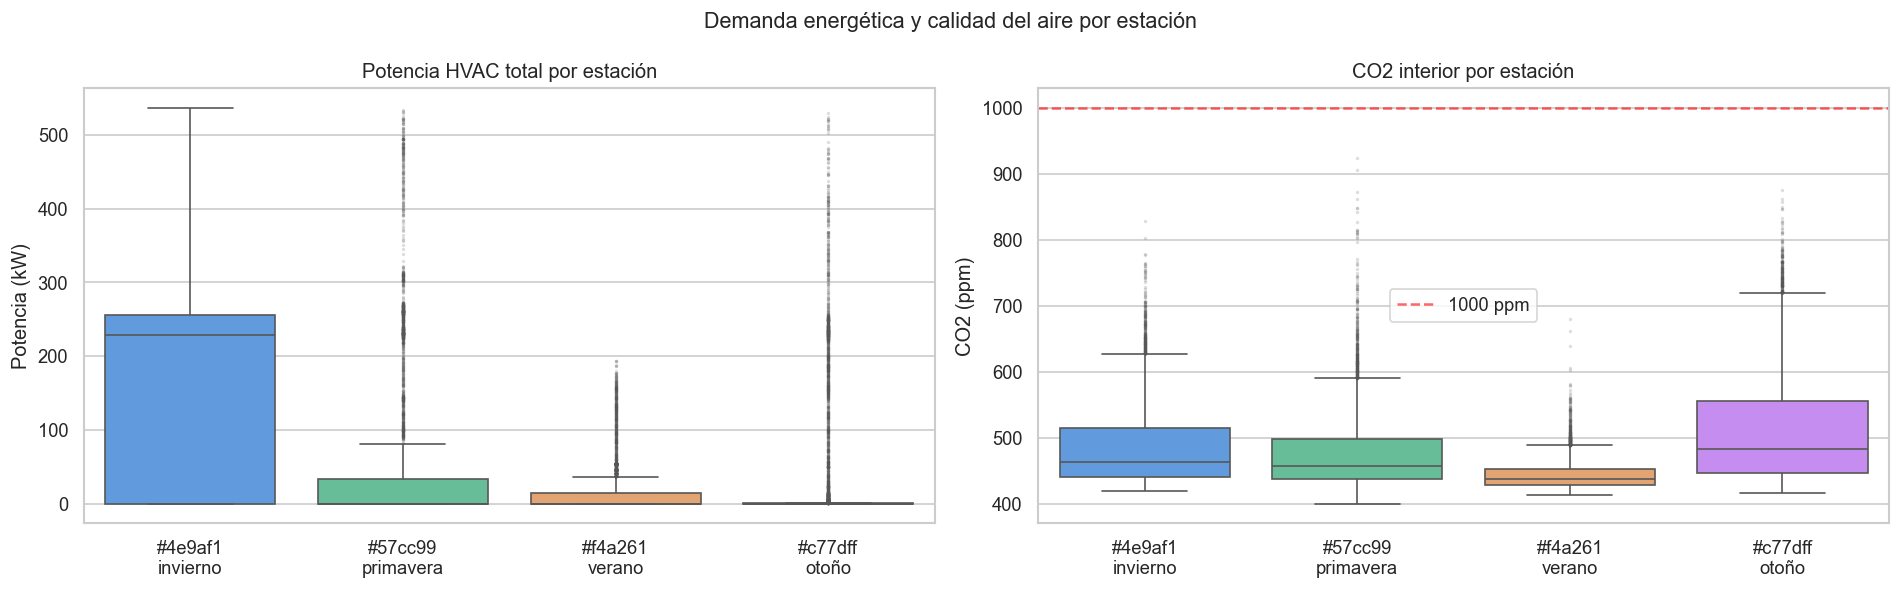

est_potencia_co2.png


In [82]:
cols_pot = [c for c in df_clean.columns if c.startswith('POT_')]
cols_co2 = [c for c in df_clean.columns if c.startswith('CO2_')]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# — Potencia HVAC —
if cols_pot:
    pot_data = []
    for est in ESTACIONES:
        df_e = dfs_est[est]
        cols_ok = [c for c in cols_pot if c in df_e.columns]
        if cols_ok:
            vals = df_e[cols_ok].sum(axis=1).resample('h').mean().dropna().values
            pot_data.append(pd.DataFrame({'valor': vals, 'estacion': est}))
    if pot_data:
        df_pot_bp = pd.concat(pot_data, ignore_index=True)
        sns.boxplot(data=df_pot_bp, x='estacion', y='valor', order=ESTACIONES,
                    palette=COLORES_EST, ax=axes[0],
                    flierprops=dict(marker='.', alpha=0.2, markersize=2))
        axes[0].set_title('Potencia HVAC total por estación', fontsize=12)
        axes[0].set_ylabel('Potencia (kW)')
        axes[0].set_xlabel('')
        axes[0].set_xticklabels([f'{COLORES_EST[e]}\n{e}' for e in ESTACIONES])
else:
    axes[0].text(0.5, 0.5, 'Sin datos de Potencia', ha='center', va='center', transform=axes[0].transAxes)

# — CO₂ —
if cols_co2:
    co2_data = []
    for est in ESTACIONES:
        df_e = dfs_est[est]
        vals = df_e[cols_co2].mean(axis=1).resample('h').mean().dropna().values
        co2_data.append(pd.DataFrame({'valor': vals, 'estacion': est}))
    df_co2_bp = pd.concat(co2_data, ignore_index=True)
    sns.boxplot(data=df_co2_bp, x='estacion', y='valor', order=ESTACIONES,
                palette=COLORES_EST, ax=axes[1],
                flierprops=dict(marker='.', alpha=0.2, markersize=2))
    axes[1].axhline(1000, color='red', linestyle='--', alpha=0.6, label='1000 ppm')
    axes[1].set_title('CO2 interior por estación', fontsize=12)
    axes[1].set_ylabel('CO2 (ppm)')
    axes[1].set_xlabel('')
    axes[1].set_xticklabels([f'{COLORES_EST[e]}\n{e}' for e in ESTACIONES])
    axes[1].legend()

plt.suptitle('Demanda energética y calidad del aire por estación', fontsize=13)
plt.tight_layout()
plt.savefig('Graficos/est_potencia_co2.png', bbox_inches='tight')
plt.show()
print('est_potencia_co2.png')

### 9.7 Perfil horario de temperatura por estación (heatmap 4 × día×hora)

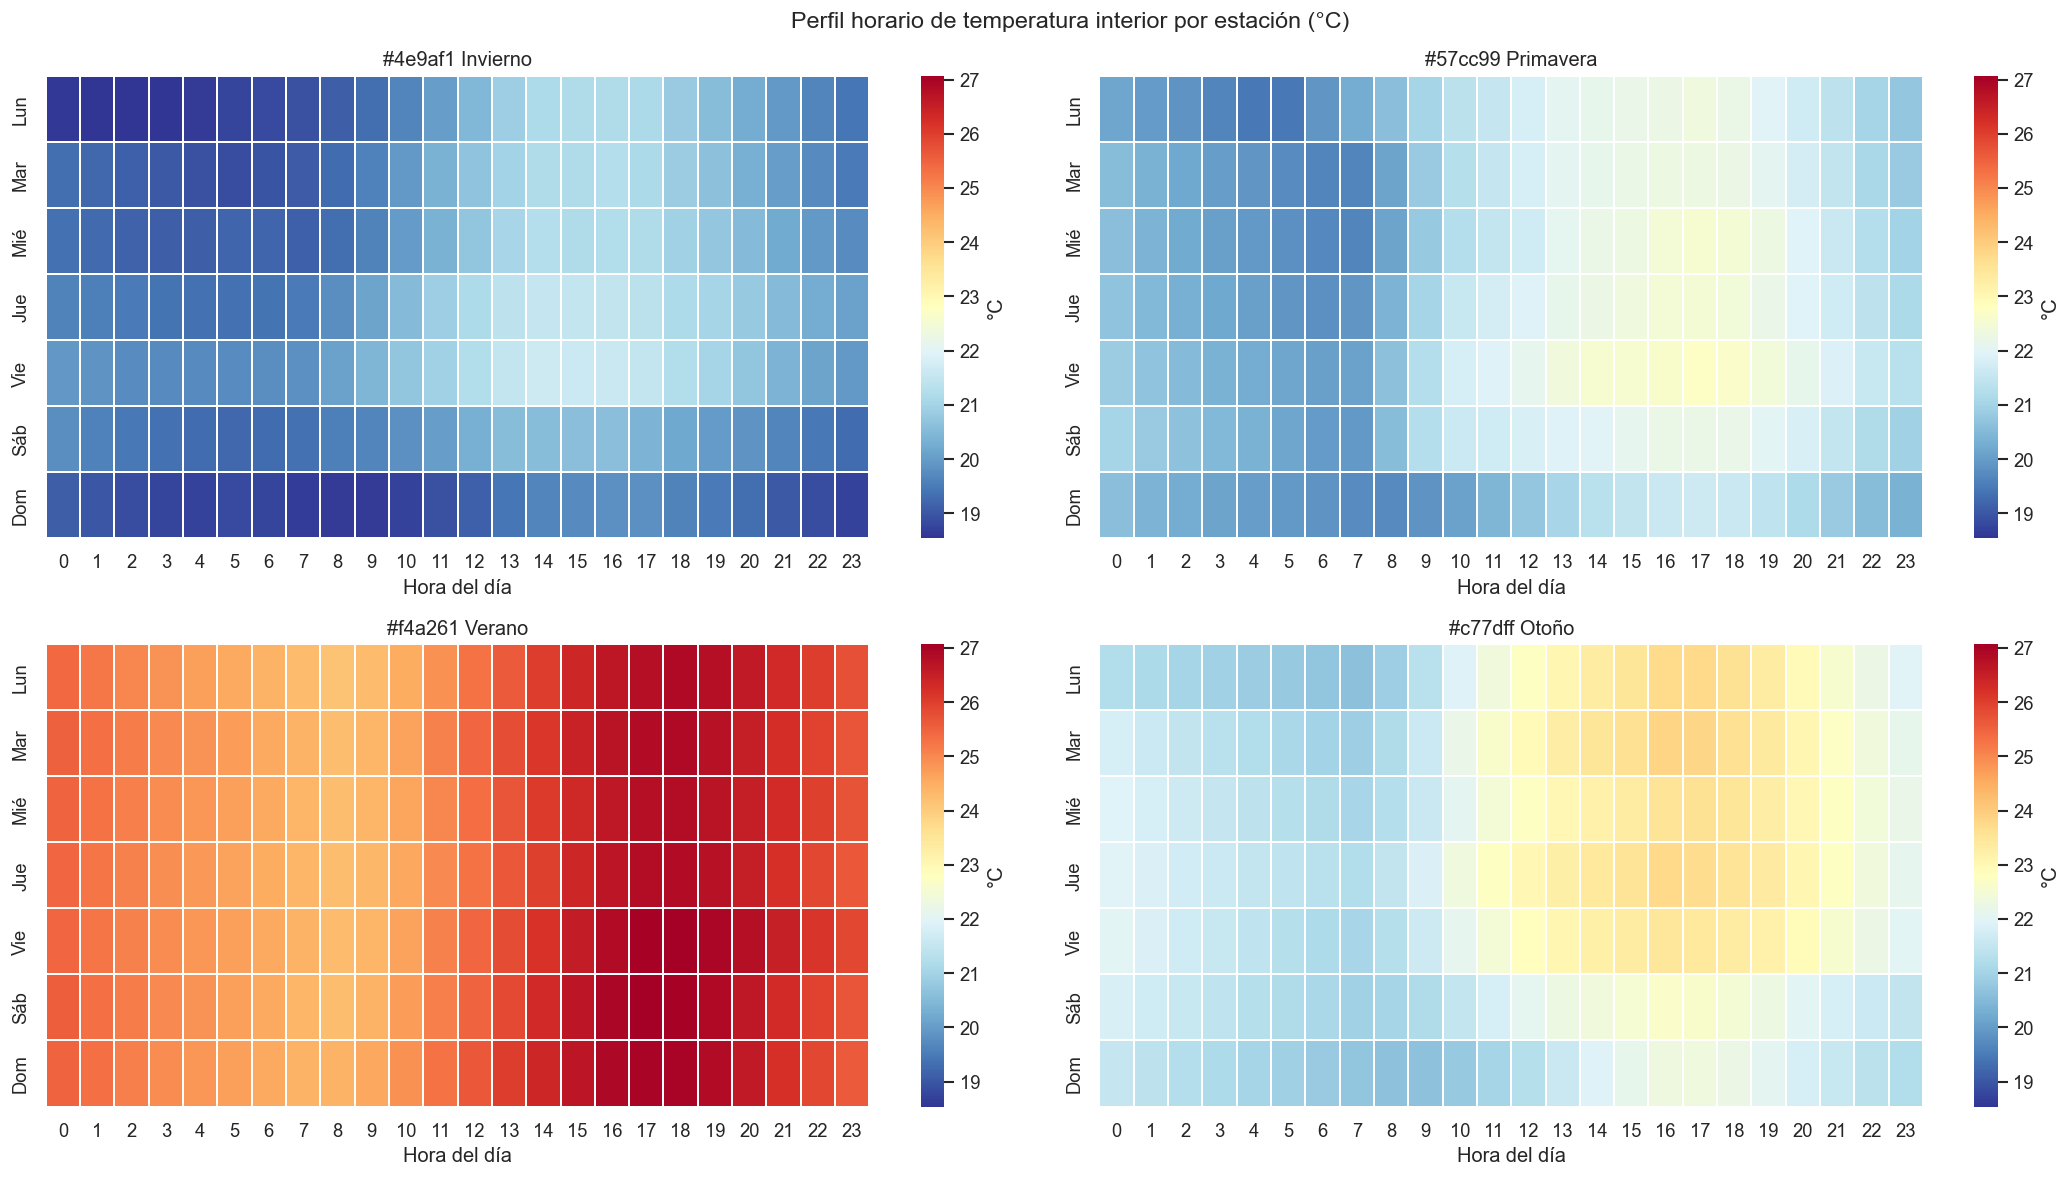

est_perfil_horario_temp.png


In [83]:
cols_ti = [c for c in df_clean.columns if c.startswith('TEMP_')
           and 'Exterior' not in c and 'Terreno' not in c]
DIAS = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

pivots = {}
for est in ESTACIONES:
    df_e  = dfs_est[est]
    media = df_e[cols_ti].mean(axis=1)
    df_hm = pd.DataFrame({'temp': media.values, 'hora': media.index.hour,
                           'dia': media.index.dayofweek})
    pivots[est] = df_hm.groupby(['dia','hora'])['temp'].mean().unstack()

vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

for i, est in enumerate(ESTACIONES):
    sns.heatmap(pivots[est], cmap='RdYlBu_r', ax=axes[i],
                vmin=vmin, vmax=vmax,
                xticklabels=range(24), yticklabels=DIAS,
                cbar_kws={'label': '°C'}, linewidths=0.1)
    axes[i].set_title(f'{COLORES_EST[est]} {est.capitalize()}', fontsize=12)
    axes[i].set_xlabel('Hora del día')
    axes[i].set_ylabel('')

plt.suptitle('Perfil horario de temperatura interior por estación (°C)', fontsize=14)
plt.tight_layout()
plt.savefig('Graficos/est_perfil_horario_temp.png', bbox_inches='tight')
plt.show()
print('est_perfil_horario_temp.png')

### 9.8 Temperatura de impulsión HVAC por estación

/var/folders/z4/45j777m57jlc9565gkrw41cr0000gn/T/ipykernel_90151/191817165.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{COLORES_EST[e]}\n{e}' for e in ESTACIONES])


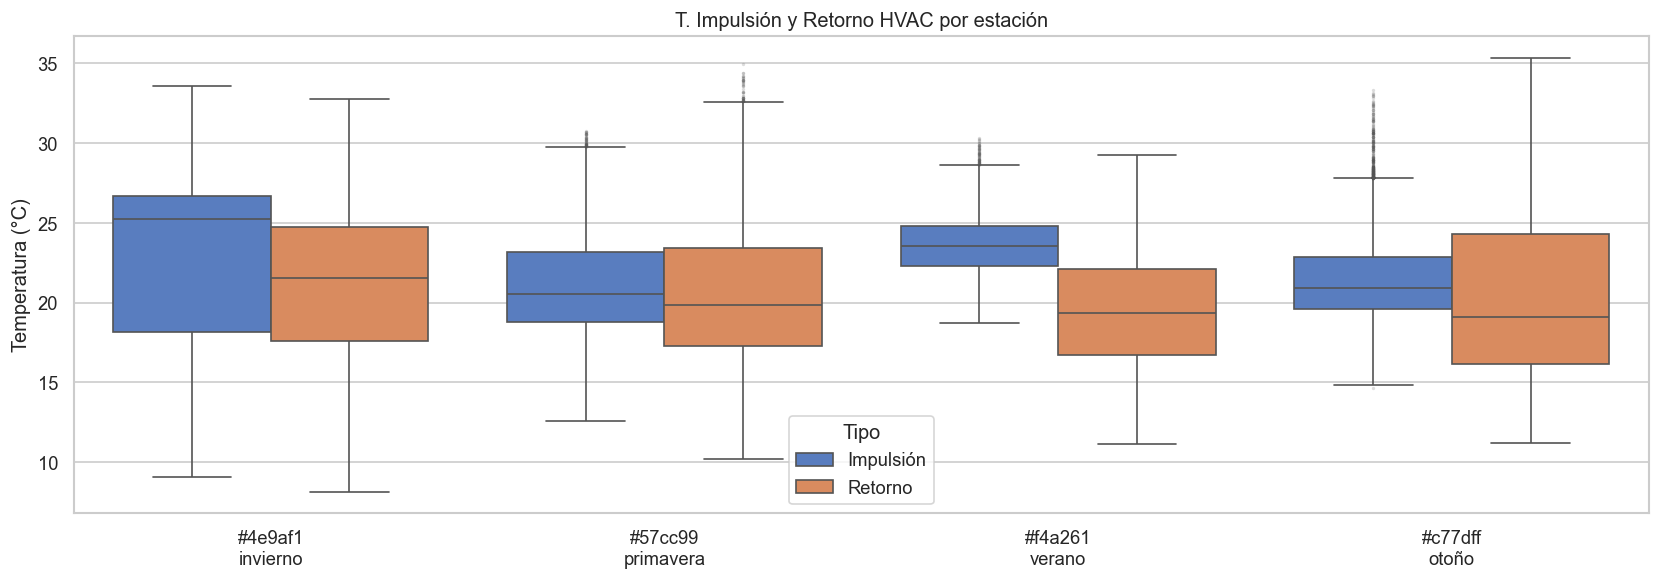

est_timp_tret.png


In [84]:
cols_imp = [c for c in df_clean.columns if c.startswith('TIMP_')]
cols_ret = [c for c in df_clean.columns if c.startswith('TRET_')]

if cols_imp:
    imp_data, ret_data = [], []
    for est in ESTACIONES:
        df_e = dfs_est[est]
        cols_i_ok = [c for c in cols_imp if c in df_e.columns]
        cols_r_ok = [c for c in cols_ret if c in df_e.columns]
        if cols_i_ok:
            vals = df_e[cols_i_ok].mean(axis=1).resample('h').mean().dropna().values
            imp_data.append(pd.DataFrame({'valor': vals, 'estacion': est, 'tipo': 'Impulsión'}))
        if cols_r_ok:
            vals = df_e[cols_r_ok].mean(axis=1).resample('h').mean().dropna().values
            ret_data.append(pd.DataFrame({'valor': vals, 'estacion': est, 'tipo': 'Retorno'}))

    df_imp_bp = pd.concat(imp_data + ret_data, ignore_index=True)

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.boxplot(data=df_imp_bp, x='estacion', y='valor', hue='tipo',
                order=ESTACIONES, ax=ax,
                flierprops=dict(marker='.', alpha=0.2, markersize=2))
    ax.set_title('T. Impulsión y Retorno HVAC por estación', fontsize=12)
    ax.set_ylabel('Temperatura (°C)')
    ax.set_xlabel('')
    ax.set_xticklabels([f'{COLORES_EST[e]}\n{e}' for e in ESTACIONES])
    ax.legend(title='Tipo')
    plt.tight_layout()
    plt.savefig('Graficos/est_timp_tret.png', bbox_inches='tight')
    plt.show()
    print('est_timp_tret.png')

---
## 10. Integración de datos meteorológicos

La estación meteorológica situada en la cubierta del edificio registra datos a **1 minuto**.
El proceso es:
1. Cargar y unificar los ~30 CSVs de la estación meteo
2. Limpiar y estandarizar columnas
3. Resamplear de 1 min → **15 min** para alinear con los datos del edificio
4. Fusionar con `df_clean` por timestamp
5. Exportar el dataset final unificado

### 10.1 Carga de CSVs de la estación meteorológica

In [85]:
import io

# ─── AJUSTA ESTA RUTA ────────────────────────────────────────────────────────
METEO_DIR = Path('Estacion Meteo') 
# ─────────────────────────────────────────────────────────────────────────────

# Columnas que nos interesan (por índice de posición, independiente del nombre)
COL_IDX = {
    'timestamp':  1,
    'temp_ext':   2,   # Temperatura exterior (°C)
    'hr_ext':     3,   # Humedad relativa exterior (%)
    'dew_point':  4,   # Punto de rocío (°C)
    'wind_speed': 5,   # Velocidad del viento (m/s)
    'solar_rad':  6,   # Radiación solar total (W/m²)
    'solar_diff': 7,   # Radiación solar difusa (W/m²)
    'rain':       8,   # Lluvia (mm)
    'wind_dir':   12,  # Dirección del viento (°)
}

def leer_meteo_robusto(path):
    """Lee un CSV de la estación meteo con cabecera malformada y encoding variable."""
    for enc in ['utf-8', 'latin-1', 'cp1252']:
        try:
            with open(path, encoding=enc) as f:
                raw = f.read()
            break
        except UnicodeDecodeError:
            continue
    # Reparar header con comilla exterior
    lines = raw.splitlines(keepends=True)
    hdr = lines[0]
    if hdr.startswith('"'):
        hdr = hdr[1:]
        if hdr.rstrip('\n').endswith('"'):
            hdr = hdr.rstrip('\n')[:-1] + '\n'
        hdr = hdr.replace('""', '"')
    lines[0] = hdr
    df = pd.read_csv(io.StringIO(''.join(lines)), low_memory=False)
    return df

def parsear_timestamp(serie):
    """Parsea timestamps y elimina zona horaria si la tuviera (normaliza a tz-naive)."""
    ts = pd.to_datetime(serie, dayfirst=True, errors='coerce', format='mixed')
    if ts.dt.tz is not None:
        ts = ts.dt.tz_localize(None) 
    return ts

meteo_files = sorted(METEO_DIR.glob('*.csv'))
print(f'Archivos meteo encontrados: {len(meteo_files)}')

dfs_meteo = []
for f in meteo_files:
    try:
        df_raw = leer_meteo_robusto(f)
        ncols  = len(df_raw.columns)
        idx    = {k: v for k, v in COL_IDX.items() if v < ncols}
        df_sel = df_raw.iloc[:, list(idx.values())].copy()
        df_sel.columns = list(idx.keys())
        df_sel['timestamp'] = parsear_timestamp(df_sel['timestamp'])
        df_sel = df_sel.dropna(subset=['timestamp'])
        for col in df_sel.columns[1:]:
            df_sel[col] = pd.to_numeric(df_sel[col], errors='coerce')
        dfs_meteo.append(df_sel)
        print(f'  {f.name}: {len(df_sel):,} filas | '
              f'{df_sel["timestamp"].min().date()} --> {df_sel["timestamp"].max().date()}')
    except Exception as e:
        print(f' {f.name}: {e}')

df_meteo_raw = pd.concat(dfs_meteo, ignore_index=True)
df_meteo_raw = df_meteo_raw.sort_values('timestamp').reset_index(drop=True)
print(f'\nTotal filas brutas: {len(df_meteo_raw):,}')
print(f'Periodo: {df_meteo_raw["timestamp"].min()} --> {df_meteo_raw["timestamp"].max()}')


Archivos meteo encontrados: 30
  20230402-730am-20230502-730am.csv: 43,190 filas | 2023-04-02 --> 2023-05-02
  20230501-15pm-20230601-10am.csv: 44,344 filas | 2023-05-01 --> 2023-06-01
  20230531-8am-20230701-10am.csv: 43,825 filas | 2023-05-31 --> 2023-07-01
  20230701-10am-20230801-1pm.csv: 44,096 filas | 2023-07-01 --> 2023-08-01
  20230801-8am-20230831-7am.csv: 43,191 filas | 2023-08-01 --> 2023-08-31
  20230829-7am-20230928-7am.csv: 43,194 filas | 2023-08-29 --> 2023-09-28
  20230926-7am-20231026-7am.csv: 43,196 filas | 2023-09-26 --> 2023-10-26
  20231025-8am-20231124-8am.csv: 43,193 filas | 2023-10-25 --> 2023-11-24
  20231122-8am-20231222-8am.csv: 43,192 filas | 2023-11-22 --> 2023-12-22
  20231220-8am-20240119-8am.csv: 43,191 filas | 2023-12-20 --> 2024-01-19
  20240119-8am-20240218-8am.csv: 43,231 filas | 2024-01-19 --> 2024-02-18
  20240218-8am-20240318-830am.csv: 41,791 filas | 2024-02-18 --> 2024-03-18
  20240318-730am-20240417-730am.csv: 43,190 filas | 2024-03-18 --> 2024

### 10.2 Limpieza y resampleo de 1 min → 15 min

In [86]:
df_meteo_raw = df_meteo_raw.set_index('timestamp')

# Eliminar duplicados temporales
n_dupl = df_meteo_raw.index.duplicated().sum()
if n_dupl > 0:
    print(f'Duplicados eliminados: {n_dupl}')
    df_meteo_raw = df_meteo_raw[~df_meteo_raw.index.duplicated(keep='first')]

# Rangos físicos — poner NaN fuera de rango
RANGOS_METEO = {
    'temp_ext':   (-30, 50),
    'hr_ext':     (0, 100),
    'dew_point':  (-40, 35),
    'wind_speed': (0, 60),
    'solar_rad':  (0, 1400),
    'solar_diff': (0, 800),
    'rain':       (0, 100),
    'wind_dir':   (0, 360),
}
for col, (vmin, vmax) in RANGOS_METEO.items():
    if col not in df_meteo_raw.columns: continue
    mask = (df_meteo_raw[col] < vmin) | (df_meteo_raw[col] > vmax)
    df_meteo_raw.loc[mask, col] = np.nan

# Resampleo a 15 min
# — media para variables continuas
cols_media = ['temp_ext', 'hr_ext', 'dew_point', 'wind_speed',
              'solar_rad', 'solar_diff', 'wind_dir']
# — suma para lluvia (acumulado en el intervalo)
cols_suma  = ['rain']

df_meteo_15 = pd.concat([
    df_meteo_raw[[c for c in cols_media if c in df_meteo_raw.columns]].resample('15min').mean(),
    df_meteo_raw[[c for c in cols_suma  if c in df_meteo_raw.columns]].resample('15min').sum(),
], axis=1)

print(f'Shape meteo a 15 min: {df_meteo_15.shape}')
print(f'Nulos por columna (%):')
print((df_meteo_15.isna().mean() * 100).round(1).to_string())

Duplicados eliminados: 46847
Shape meteo a 15 min: (97541, 8)
Nulos por columna (%):
temp_ext      1.100
hr_ext        1.300
dew_point     1.200
wind_speed   27.400
solar_rad     0.000
solar_diff    0.300
wind_dir      6.900
rain          0.000


### 10.3 Fusión con el dataset del edificio

In [87]:
# Añadir prefijo 'meteo_' para distinguir claramente las columnas
df_meteo_15.columns = ['meteo_' + c for c in df_meteo_15.columns]

# Join por timestamp (left: conserva todos los registros del edificio)
df_final = df_clean.join(df_meteo_15, how='left')

# Cobertura de la meteo sobre el periodo del edificio
cobertura = df_final['meteo_temp_ext'].notna().mean() * 100
print(f'Cobertura meteo sobre periodo edificio: {cobertura:.1f} %')
print(f'Shape dataset final: {df_final.shape}')
print(f'Periodo: {df_final.index.min()} --> {df_final.index.max()}')
print(f'\nColumnas meteo añadidas:')
for c in df_final.columns[df_final.columns.str.startswith('meteo_')]:
    pct_ok = df_final[c].notna().mean() * 100
    print(f'  {c:<25} {pct_ok:.1f} % datos')

Cobertura meteo sobre periodo edificio: 98.8 %
Shape dataset final: (90383, 120)
Periodo: 2023-05-12 12:15:00 --> 2025-12-08 23:45:00

Columnas meteo añadidas:
  meteo_temp_ext            98.8 % datos
  meteo_hr_ext              99.2 % datos
  meteo_dew_point           99.7 % datos
  meteo_wind_speed          70.4 % datos
  meteo_solar_rad           100.0 % datos
  meteo_solar_diff          99.9 % datos
  meteo_wind_dir            92.5 % datos
  meteo_rain                100.0 % datos


### 10.4 Exportación del dataset final unificado

In [88]:
df_final.to_csv('E3Lab_final.csv')
print(f'Dataset final guardado: E3Lab_final.csv')
print(f'   {df_final.shape[0]:,} filas y {df_final.shape[1]} columnas')
print(f'   Tamaño aprox: {os.path.getsize("E3Lab_final.csv")/1e6:.1f} MB')

Dataset final guardado: E3Lab_final.csv
   90,383 filas y 120 columnas
   Tamaño aprox: 62.1 MB


---
## 11. Feature Engineering

Antes de modelar, construimos las variables que el modelo usará como inputs:

| Grupo | Variables |
|---|---|
| **Temporales** | hora, día semana, mes, estación, calendario_lectivo |
| **Lag features** | Energía usada t-1, t-4, t-8, t-96, t-672 (15 min, 1 h, 2 h, 24 h, 1 semana) |
| **Medias móviles** | Energía usada media 1 h, 6 h, 24 h |
| **Meteorológicas** | temp_ext, solar_rad, rain, wind_speed (directas) |
| **Del edificio** | temp interior media, humedad media, CO₂ medio |

**Variable objetivo:** `target_energia_15min_hvac` = energía HVAC usada durante los 15 minutos anteriores, calculada como diferencia de los contadores acumulados `ENER_`

> **Referencias:** La selección de horizontes temporales para las variables retardadas sigue las pautas de Lazzeri (2020), quien propone construir *nested lag features* agrupando el consumo en períodos fijos del pasado (hora anterior, días anteriores, semana anterior). Deb et al. (2017) confirman que en la predicción de consumo energético en edificios los modelos ANN emplean de forma estándar variables retardadas a corto plazo (t-1, t-2, t-3) junto con variables temporales (hora del día, día de la semana), y validan el uso de datos con granularidad de 15 min para predicción sub-horaria en edificios comerciales [Chae et al., citado en Deb et al.].

### 11.1 Construcción de la variable objetivo

In [89]:
df_final = df_final.sort_index()
cols_ener = [c for c in df_final.columns if c.startswith('ENER_')]
print(f'Contadores de energía acumulada disponibles: {len(cols_ener)}')
for c in cols_ener:
    print(f'  {c}')

# La energía acumulada se transforma en energía usada en el intervalo anterior.
# Para datos a 15 min: consumo(t) = energía_acumulada(t) - energía_acumulada(t-15 min).
energia_acumulada = df_final[cols_ener].sort_index()
delta_energia = energia_acumulada.diff()

# Evitar consumos artificiales cuando hay saltos temporales o reinicios de contador.
intervalo_15min = pd.Series(df_final.index.to_series().diff().eq(pd.Timedelta(minutes=15)).to_numpy(),
                            index=df_final.index)
delta_energia = delta_energia.where(intervalo_15min, np.nan)
delta_energia = delta_energia.mask(delta_energia < 0)

df_final['target_energia_15min_hvac'] = delta_energia.sum(axis=1, min_count=1)

pct_target = df_final['target_energia_15min_hvac'].notna().mean() * 100
print(f'\nCobertura de la variable objetivo: {pct_target:.1f} %')
print(df_final['target_energia_15min_hvac'].describe().round(3))

n_reinicios = int((energia_acumulada.diff() < 0).sum().sum())
print(f'Lecturas descartadas por reinicio/descenso del contador: {n_reinicios:,}')

Contadores de energía acumulada disponibles: 3
  ENER_d59_PS_Maquinas_B
  ENER_d60_P1_Maquinas_Exterior
  ENER_d61_P1_Maquinas_Exterior

Cobertura de la variable objetivo: 82.5 %
count   74595.000
mean        1.778
std         3.180
min         0.000
25%         0.000
50%         0.000
75%         3.000
max        14.000
Name: target_energia_15min_hvac, dtype: float64
Lecturas descartadas por reinicio/descenso del contador: 0


### 11.2 Features temporales

In [90]:
df_final['hora']       = df_final.index.hour
df_final['dia_semana'] = df_final.index.dayofweek      # 0=Lun, 6=Dom
df_final['mes']        = df_final.index.month
df_final['dia_anyo']   = df_final.index.dayofyear

# Calendario académico UNAV, campus Pamplona.
# 1 = día de operación normal del edificio; 0 = fines de semana, festivos y vacaciones.
PERIODOS_OPERACION_NORMAL = [
    ('2023-09-04', '2024-06-29'),
    ('2024-09-02', '2025-06-27'),
]

PERIODOS_VACACIONES = [
    ('2023-12-22', '2024-01-05'),  # Navidad 2023-2024
    ('2024-03-25', '2024-04-06'),  # Semana Santa y Pascua 2023-2024
    ('2024-07-01', '2024-08-31'),  # verano 2023-2024
    ('2024-12-20', '2025-01-07'),  # Navidad 2024-2025
    ('2025-04-14', '2025-04-26'),  # Semana Santa y Pascua 2024-2025
    ('2025-06-28', '2025-08-30'),  # verano 2024-2025
]

FESTIVOS_UNAV_PAMPLONA = pd.to_datetime([
    # Curso 2023-2024
    '2023-10-12', '2023-11-01', '2023-11-29', '2023-12-04',
    '2023-12-06', '2023-12-08', '2024-01-28', '2024-03-19',
    '2024-05-01', '2024-06-26',
    # Curso 2024-2025
    '2024-10-12', '2024-11-01', '2024-11-29', '2024-12-03',
    '2024-12-06', '2024-12-08', '2025-01-28', '2025-03-19',
    '2025-05-01', '2025-06-26',
]).normalize()

fecha = pd.Series(df_final.index.normalize(), index=df_final.index)
es_laborable = pd.Series(df_final.index.dayofweek < 5, index=df_final.index)

en_periodo_operacion = pd.Series(False, index=df_final.index)
for inicio, fin in PERIODOS_OPERACION_NORMAL:
    en_periodo_operacion |= fecha.between(pd.Timestamp(inicio), pd.Timestamp(fin))

en_vacaciones = pd.Series(False, index=df_final.index)
for inicio, fin in PERIODOS_VACACIONES:
    en_vacaciones |= fecha.between(pd.Timestamp(inicio), pd.Timestamp(fin))

es_festivo = fecha.isin(FESTIVOS_UNAV_PAMPLONA)
df_final['calendario_lectivo'] = (
    es_laborable & en_periodo_operacion & ~en_vacaciones & ~es_festivo
).astype(int)

def mes_a_estacion_num(mes):
    if mes in [3, 4, 5]:   return 1  # primavera
    if mes in [6, 7, 8]:   return 2  # verano
    if mes in [9, 10, 11]: return 3  # otoño
    return 0                          # invierno

df_final['estacion_num'] = df_final['mes'].map(mes_a_estacion_num)

# Codificación cíclica de hora y día (para modelos que no entienden circularidad)
df_final['hora_sin'] = np.sin(2 * np.pi * df_final['hora'] / 24)
df_final['hora_cos'] = np.cos(2 * np.pi * df_final['hora'] / 24)
df_final['dia_sin']  = np.sin(2 * np.pi * df_final['dia_semana'] / 7)
df_final['dia_cos']  = np.cos(2 * np.pi * df_final['dia_semana'] / 7)
df_final['mes_sin']  = np.sin(2 * np.pi * df_final['mes'] / 12)
df_final['mes_cos']  = np.cos(2 * np.pi * df_final['mes'] / 12)

print('Features temporales creadas:')
feats_temp = ['hora','dia_semana','mes','dia_anyo','calendario_lectivo','estacion_num',
              'hora_sin','hora_cos','dia_sin','dia_cos','mes_sin','mes_cos']
print('  ' + ', '.join(feats_temp))
print(f"Días de operación normal: {df_final['calendario_lectivo'].mean() * 100:.1f} % de los registros")

Features temporales creadas:
  hora, dia_semana, mes, dia_anyo, calendario_lectivo, estacion_num, hora_sin, hora_cos, dia_sin, dia_cos, mes_sin, mes_cos
Días de operación normal: 39.2 % de los registros


### 11.3 Lag features y medias móviles de la energía usada

La elección de los horizontes de retardo se apoya en dos criterios:

1. **Autocorrelación a corto plazo** — el consumo en el intervalo inmediatamente anterior (t-1, ±15 min) y en la última hora (t-4) capturan la inercia térmica inmediata del sistema HVAC. Deb et al. (2017) señalan que los modelos ANN para edificios utilizan habitualmente valores retardados a t-1, t-2 y t-3 como variables de entrada, junto a variables climáticas y temporales (Karatasou et al., citado en Deb et al., 2017).

2. **Patrones periódicos diarios y semanales** — el consumo HVAC muestra periodicidad diaria (misma hora del día anterior, t-96) y semanal (mismo instante de la semana anterior, t-672), patrón característico de edificios de uso académico con horarios regulares. Lazzeri (2020, cap. 3) describe explícitamente este enfoque de *nested lag features* — horas anteriores, días anteriores y semana anterior — como práctica estándar en series temporales con estacionalidad múltiple.

Las **medias móviles** (1 h, 6 h, 24 h) complementan los lags puntuales proporcionando una visión suavizada del comportamiento reciente, técnica también descrita en Lazzeri (2020) como *Rolling Window Statistics*.

**Bibliografía:**
- Deb, C., Zhang, F., Yang, J., Lee, S.E., Shah, K.W. (2017). *A review on time series forecasting techniques for building energy consumption.* Renewable and Sustainable Energy Reviews, 74, 902-924.
- Lazzeri, F. (2020). *Machine Learning for Time Series Forecasting with Python.* Wiley, cap. 3 (Lag Features and Window Features, pp. 92-97).

In [91]:
energia_15min = df_final['target_energia_15min_hvac']

# Lags (cada unidad = 15 min)
LAGS = {
    'energia_lag_1':  1,    # 15 min antes
    'energia_lag_4':  4,    # 1 hora antes
    'energia_lag_8':  8,    # 2 horas antes
    'energia_lag_96': 96,   # 24 horas antes
    'energia_lag_672': 672, # 1 semana antes
}
for nombre, n in LAGS.items():
    df_final[nombre] = energia_15min.shift(n)

# Medias móviles de la energía usada en intervalos anteriores
ROLLING = {
    'energia_roll_1h':  4,    # 1 hora
    'energia_roll_6h':  24,   # 6 horas
    'energia_roll_24h': 96,   # 24 horas
}
for nombre, ventana in ROLLING.items():
    df_final[nombre] = energia_15min.shift(1).rolling(ventana, min_periods=1).mean()

print('Lag features:', list(LAGS.keys()))
print('Rolling mean features:', list(ROLLING.keys()))

Lag features: ['energia_lag_1', 'energia_lag_4', 'energia_lag_8', 'energia_lag_96', 'energia_lag_672']
Rolling mean features: ['energia_roll_1h', 'energia_roll_6h', 'energia_roll_24h']


### 11.4 Agregados del edificio como features

In [92]:
cols_ti  = [c for c in df_final.columns if c.startswith('TEMP_')
            and 'Exterior' not in c and 'Terreno' not in c
            and not c.startswith('meteo_')]
cols_hum = [c for c in df_final.columns if c.startswith('HUM_')]
cols_co2 = [c for c in df_final.columns if c.startswith('CO2_')]
cols_timp= [c for c in df_final.columns if c.startswith('TIMP_')]

if cols_ti:   df_final['temp_int_media']  = df_final[cols_ti].mean(axis=1)
if cols_hum:  df_final['hum_int_media']   = df_final[cols_hum].mean(axis=1)
if cols_co2:  df_final['co2_medio']       = df_final[cols_co2].mean(axis=1)
if cols_timp: df_final['timp_media']      = df_final[cols_timp].mean(axis=1)

# Diferencia temperatura interior - exterior (clave para HVAC)
if 'meteo_temp_ext' in df_final.columns and cols_ti:
    df_final['delta_temp'] = df_final['temp_int_media'] - df_final['meteo_temp_ext']

print('Features agregadas del edificio creadas:')
feats_edif = ['temp_int_media','hum_int_media','co2_medio','timp_media','delta_temp']
for f in feats_edif:
    if f in df_final.columns:
        pct = df_final[f].notna().mean() * 100
        print(f'  {f:<20} {pct:.1f} % datos')

Features agregadas del edificio creadas:
  temp_int_media       99.5 % datos
  hum_int_media        99.5 % datos
  co2_medio            99.5 % datos
  timp_media           98.2 % datos
  delta_temp           98.4 % datos


### 11.5 Dataset de modelado final

In [93]:
# Features que entran al modelo
FEATURES = [
    # Temporales
    'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'mes_sin', 'mes_cos',
    'calendario_lectivo', 'estacion_num',
    # Lags y rolling
    'energia_lag_1', 'energia_lag_4', 'energia_lag_8', 'energia_lag_96', 'energia_lag_672',
    'energia_roll_1h', 'energia_roll_6h', 'energia_roll_24h',
    # Meteorología
    'meteo_temp_ext', 'meteo_hr_ext', 'meteo_solar_rad',
    'meteo_solar_diff', 'meteo_rain', 'meteo_wind_speed',
    # Edificio
    'temp_int_media', 'hum_int_media', 'co2_medio', 'timp_media', 'delta_temp',
]

TARGET = 'target_energia_15min_hvac'

# Filtrar solo columnas disponibles
FEATURES = [f for f in FEATURES if f in df_final.columns]

# Dataset de modelado: solo filas con target válido
df_model = df_final[FEATURES + [TARGET]].dropna(subset=[TARGET])

print(f'Features seleccionadas: {len(FEATURES)}')
print(f'Filas con target válido: {len(df_model):,}')
print(f'Filas con algún NaN en features: {df_model[FEATURES].isna().any(axis=1).sum():,}')
print(f'\nVariable objetivo — estadísticas:')
print(df_model[TARGET].describe().round(3))

# Exportar
df_model.to_csv('E3Lab_modelo.csv')
print(f'\nDataset de modelado guardado: E3Lab_modelo.csv')
print(f'   {df_model.shape[0]:,} filas y {df_model.shape[1]} columnas')

Features seleccionadas: 27
Filas con target válido: 74,595
Filas con algún NaN en features: 27,854

Variable objetivo — estadísticas:
count   74595.000
mean        1.778
std         3.180
min         0.000
25%         0.000
50%         0.000
75%         3.000
max        14.000
Name: target_energia_15min_hvac, dtype: float64

Dataset de modelado guardado: E3Lab_modelo.csv
   74,595 filas y 28 columnas


### 11.6 Correlación de features con la variable objetivo

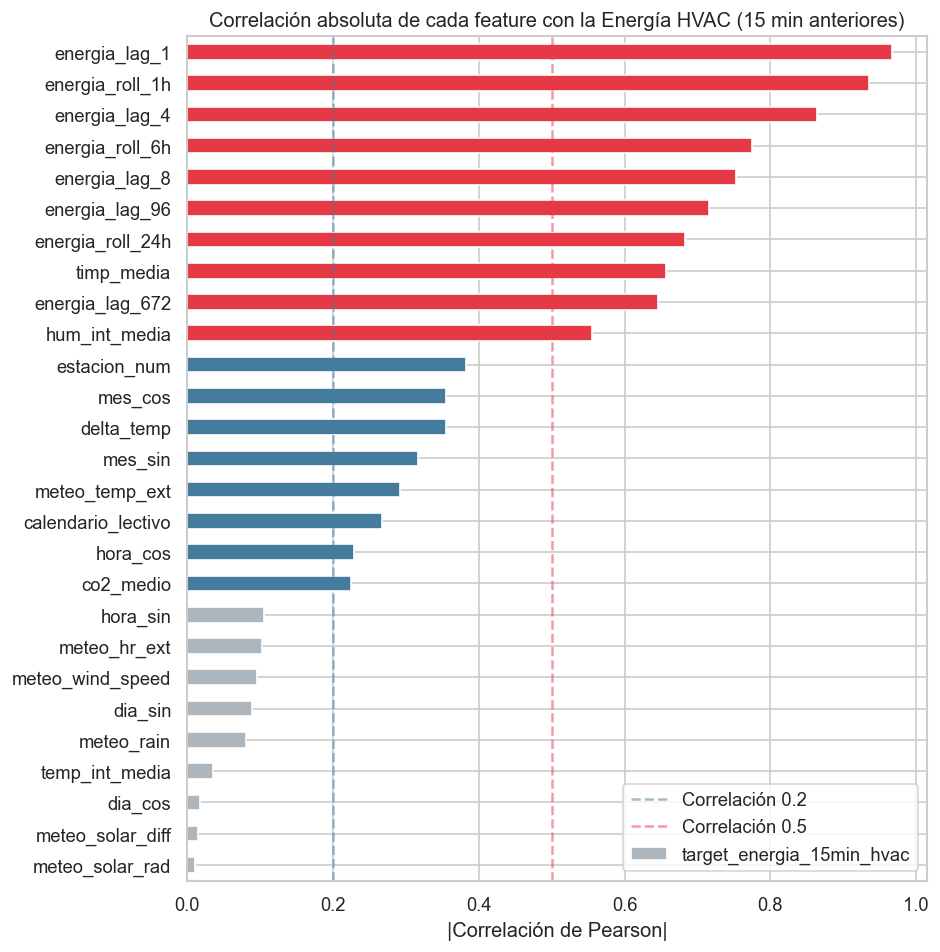

feat_correlacion_target.png


In [94]:
corr_target = df_model[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET)
corr_target = corr_target.abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(5, len(corr_target) * 0.3)))
colors = ['#e63946' if v > 0.5 else '#457b9d' if v > 0.2 else '#adb5bd'
          for v in corr_target.values]
corr_target.plot.barh(ax=ax, color=colors, edgecolor='white')
ax.axvline(0.2, color='#457b9d', linestyle='--', alpha=0.5, label='Correlación 0.2')
ax.axvline(0.5, color='#e63946', linestyle='--', alpha=0.5, label='Correlación 0.5')
ax.set_title('Correlación absoluta de cada feature con la Energía HVAC (15 min anteriores)', fontsize=12)
ax.set_xlabel('|Correlación de Pearson|')
ax.legend()
plt.tight_layout()
plt.savefig('Graficos/meteo/feat_correlacion_target.png', bbox_inches='tight')
plt.show()
print('feat_correlacion_target.png')